# TrustGuard — Track 2: Financial Fraud Detection
**Team Top 4 MCDs** · NTU DLW Datathon 2026 · Marcus (data, cleaning, business impact) · Germaine (features, model comparison, explainability, robustness) · Jay (readability) · Pin Wei (report and poster)

**Goal:** estimate the probability that a transaction is fraudulent, and turn it into a cost-based alert policy that catches fraud without blocking honest customers.

> ### Executive summary
> - **Data:** 20,000 training transactions; **353 (1.76%, 1 in 57) are fraud** but carry **4.0% of the dollars**. 12,000 test transactions, label hidden.
> - **Model:** logistic regression on 29 engineered features, **PR-AUC 0.2341 ± 0.0365**, **13.3×** better than guessing (0.0176) and ahead of an untuned LightGBM baseline (0.1952 ± 0.0448). Fancier models did not beat it.
> - **Test shift:** a classifier tells training from test rows with **AUC 0.668**; test has 3.5× more blanks. We neutralised a data trap (blank values are *never* fraud in training: 0 of 113, 0 of 124 rows) and scored every model on a "test-like" slice too.
> - **Value:** alert when *probability × amount* exceeds an assumed \$5 review cost → flags **17.0%** of transactions in our practice tests (about 23% on the test file, whose payments are larger; Section 10), catches **92.1% of fraud dollars**, saves **\$84,309 per 10,000 transactions** vs **\$80,200** for "flag everything over \$500".
> - **Ceiling:** about 1 in 6 frauds shows no observable signal; no model catches those (Section 9).

| Section | Question it answers |
|---|---|
| 1 | Why is this hard, and what does a mistake cost? |
| 2 | What is in the data, what does fraud look like, how is the test set different? |
| 3 | How do we clean the data without teaching the model a false pattern? |
| 4 | Which features do we build, and why? |
| 5 | How good is a baseline, and do hand-made features help a tree? |
| 6 | Which model wins, and which do we ship? |
| 7 | Can the probabilities be trusted, do they survive a shifted test set, what are they worth? |
| 8 | Why does the model flag a transaction, and who gets disrupted? |
| 9 | Limitations and next steps |
| 10 | How the submission files were produced (no analysis, reproducibility only) |

**Terms used in this notebook**

| Term | Meaning |
|---|---|
| **Base rate** | The share of transactions that are fraud knowing nothing else: 1.76%. |
| **PR-AUC** | The competition's score: how well frauds are ranked above legitimate transactions. 0.0176 = guessing, 1.0 = perfect; not fooled by the 98% legitimate majority. |
| **Precision / recall** | Of flagged transactions, the share that are fraud; of all frauds, the share flagged. |
| **False alarm** | A legitimate transaction that gets flagged: a blocked customer plus a review cost. |
| **Cross-validation (CV)** | Train on part of the data, score on the hidden rest, rotate, repeat ("3×5" = five parts, three repeats). We report mean ± spread across parts. |
| **Out-of-fold (OOF) probability** | The score a model gave a training row while that row was hidden from it — an honest stand-in for unseen data. |
| **Calibration / Brier score** | "10% risk" really means 1 in 10. Brier measures it; lower is better (guessing the base rate: 0.0173). |
| **Test-like slice** | The 20% of training rows a classifier finds most similar to the test set; every model is also scored there. |


## 0. Setup and data
**Run the setup cell below first, before anything else, in a clean Colab** to make sure the notebook runs smoothly. It imports standard libraries only (no `src/` imports, no API keys). The cell after it then finds the two CSV files, in the repo layout, the Colab working directory, or under the organisers' original filenames.


In [1]:
# Setup — single cell, Colab-safe. Everything below uses only these imports.
import os, sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from IPython.display import display, Markdown
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold, RepeatedStratifiedKFold
from sklearn.metrics import (average_precision_score, f1_score, recall_score,
                             precision_recall_curve, brier_score_loss, roc_auc_score)
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import VotingClassifier

warnings.filterwarnings("ignore", category=UserWarning)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option("display.max_columns", 50)
print("python", sys.version.split()[0], "| pandas", pd.__version__, "| lightgbm", lgb.__version__)


python 3.13.6 | pandas 2.2.3 | lightgbm 4.5.0


In [2]:
# Locate the data (repo layout, Colab working dir, or raw organiser filenames).
def find_csv(names, required=True):
    roots = [Path("."), Path(".."), Path("../data/raw/track2"), Path("data/raw/track2"),
             Path("/content"), Path("/content/Track 2 Dataset")]
    for r in roots:
        for n in names:
            p = r / n
            if p.exists():
                return p
    if required:
        raise FileNotFoundError(f"Place the Track 2 CSVs next to this notebook: {names}")
    return None   # optional file (e.g. sample_submission.csv) simply absent

TRAIN_PATH = find_csv(["train.csv", "Track 2 Training Dataset.csv"])
TEST_PATH  = find_csv(["test.csv",  "Track 2 Testing Dataset.csv"])
train = pd.read_csv(TRAIN_PATH)
test  = pd.read_csv(TEST_PATH)
TARGET, ID_COL = "fraud", "id"
print(TRAIN_PATH, train.shape, "|", TEST_PATH, test.shape)


../data/raw/track2/train.csv (20000, 12) | ../data/raw/track2/test.csv (12000, 11)


## 1. Understanding the problem
A bank must stop fraud **without blocking honest customers** — the brief says "minimising unnecessary disruption to legitimate customers". That trade-off, not accuracy, is what this notebook optimises.


### 1.1 How rare is fraud, by count and by dollars?
Accuracy rewards agreeing with the majority, so we first need fraud's share by count *and* by money.


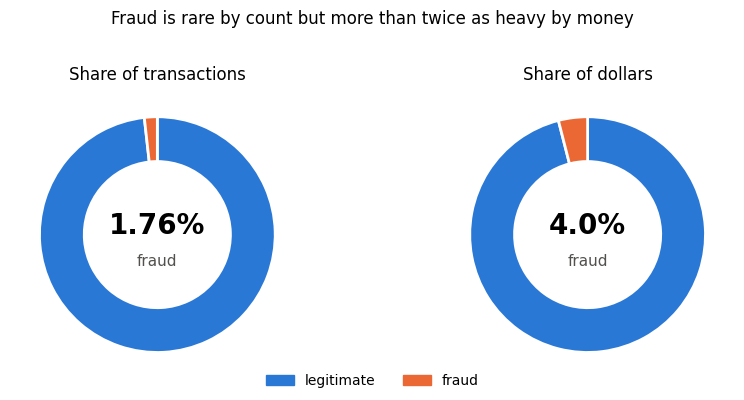


| | Transactions | Dollars |
|---|---|---|
| **Fraud** | **353** of 20,000 = **1.76%** (1 in 57) | **\$201,495** of \$5,053,277 = **4.0%** |
| "Never fraud" model | accuracy **98.2%**, frauds caught **0 of 353** | — |


In [3]:
# 1.1 Rare by count, heavier by dollars - the two numbers behind "accuracy is the wrong yardstick"
LEGIT_C, FRAUD_C = "#2a78d6", "#eb6834"          # one fixed colour per class, used in every chart of this notebook
n_fraud, n_all = int(train[TARGET].sum()), len(train)
rate = n_fraud / n_all
dollars = train.groupby(TARGET)["transaction_amount"].sum()
dollar_share = dollars[1] / dollars.sum()
naive_accuracy = 1 - rate                         # a model that never flags anything

fig, axes = plt.subplots(1, 2, figsize=(9, 3.8))
for ax, shares, title, hero in [(axes[0], (1 - rate, rate), "Share of transactions", f"{rate:.2%}"),
                                (axes[1], (1 - dollar_share, dollar_share), "Share of dollars", f"{dollar_share:.1%}")]:
    ax.pie(shares, colors=[LEGIT_C, FRAUD_C], startangle=90, counterclock=False,
           wedgeprops=dict(width=0.38, edgecolor="white", linewidth=2))
    ax.text(0, 0.08, hero, ha="center", va="center", fontsize=20, fontweight="bold")
    ax.text(0, -0.22, "fraud", ha="center", va="center", fontsize=11, color="#52514e")
    ax.set_title(title, fontsize=12)
fig.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=LEGIT_C), plt.Rectangle((0, 0), 1, 1, color=FRAUD_C)],
           labels=["legitimate", "fraud"], loc="lower center", ncol=2, frameon=False)
fig.suptitle("Fraud is rare by count but more than twice as heavy by money", fontsize=12, y=1.02)
plt.tight_layout(); plt.show()

display(Markdown(f"""
| | Transactions | Dollars |
|---|---|---|
| **Fraud** | **{n_fraud:,}** of {n_all:,} = **{rate:.2%}** (1 in {1 / rate:.0f}) | **\\${dollars[1]:,.0f}** of \\${dollars.sum():,.0f} = **{dollar_share:.1%}** |
| "Never fraud" model | accuracy **{naive_accuracy:.1%}**, frauds caught **0 of {n_fraud}** | — |
"""))
# Takeaway: 1.77% of transactions but ~4% of the money - the thin orange sliver on the left is what every 'accurate' model ignores.

**What we found**
- **353 of 20,000** transactions are fraud: **1.76%**, about 1 in 57 — yet they carry **4.0% of all dollars** (**\$201,495** of \$5,053,277).
- A model that never flags anything is **98.2% accurate** and catches **0 of 353** frauds.

**Implications:** accuracy is meaningless here, so we score on **PR-AUC** and report precision, recall and fraud dollars at an operating point; with only 353 examples, every score is a mean over repeated cross-validation.


### 1.2 How much does a missed fraud cost?
A missed fraud costs the whole transaction; a false alarm costs a review. The size of a typical fraud decides how to weigh the two.


,count,mean,median,total
fraud,,,,
legitimate,19647,246.95,74.26,4851782.43
fraud,353,570.81,224.26,201494.76


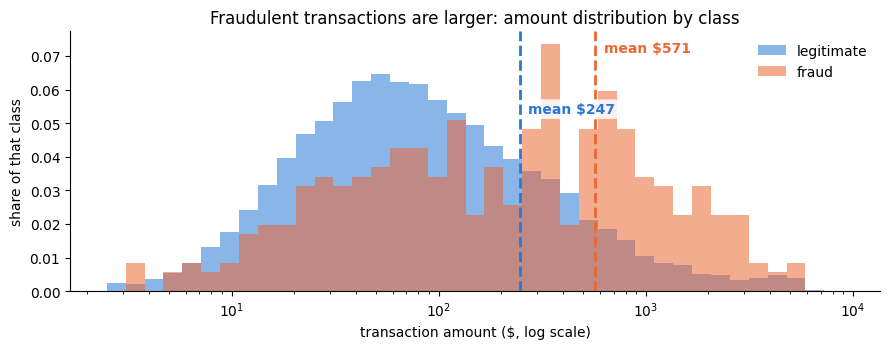


- Mean fraud \$571 *vs* mean legitimate \$247 → **2.3× larger** (medians \$224 *vs* \$74).
- A missed fraud costs its full amount, so **the average miss costs ≈ \$571**.
- Total fraud exposure in the training data: **\$201,495**.


In [4]:
# 1.2 Where "a missed fraud costs ~$571" comes from: amount by class, computed and drawn
cost = (train.groupby(TARGET)["transaction_amount"]
             .agg(count="count", mean="mean", median="median", total="sum")
             .rename(index={0: "legitimate", 1: "fraud"}).round(2))
display(cost)

fig, ax = plt.subplots(figsize=(9, 3.6))
bins = np.logspace(np.log10(train.transaction_amount.min()), np.log10(train.transaction_amount.max()), 40)
for label, colour in [("legitimate", LEGIT_C), ("fraud", FRAUD_C)]:
    amt = train.loc[train[TARGET] == (label == "fraud"), "transaction_amount"]
    ax.hist(amt, bins=bins, weights=np.full(len(amt), 1 / len(amt)), alpha=0.55, color=colour, label=label)
    m = cost.loc[label, "mean"]
    ax.axvline(m, color=colour, ls="--", lw=2)
    ax.annotate(f"mean ${m:,.0f}", xy=(m, ax.get_ylim()[1] * (0.92 if label == "fraud" else 0.78)),
                xytext=(6, 0), textcoords="offset points", color=colour, fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.85))
ax.set_xscale("log"); ax.set_xlabel("transaction amount ($, log scale)"); ax.set_ylabel("share of that class")
ax.set_title("Fraudulent transactions are larger: amount distribution by class"); ax.legend(frameon=False)
for s in ("top", "right"): ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

ratio = cost.loc["fraud", "mean"] / cost.loc["legitimate", "mean"]
display(Markdown(f"""
- Mean fraud \\${cost.loc['fraud', 'mean']:,.0f} *vs* mean legitimate \\${cost.loc['legitimate', 'mean']:,.0f} → **{ratio:.1f}× larger** (medians \\${cost.loc['fraud', 'median']:,.0f} *vs* \\${cost.loc['legitimate', 'median']:,.0f}).
- A missed fraud costs its full amount, so **the average miss costs ≈ \\${cost.loc['fraud', 'mean']:,.0f}**.
- Total fraud exposure in the training data: **\\${cost.loc['fraud', 'total']:,.0f}**.
"""))
# Takeaway: the orange distribution sits to the right of the blue one - frauds are bigger transactions, which is why
# we report fraud DOLLARS caught (not just cases) and why Section 7.3 weighs each alert by its amount.

**What we found**
- Average fraud **\$570.81** vs average legitimate transaction **\$246.95**: **2.3× larger** (medians 224 vs 74).
- The two distributions overlap heavily: amount alone cannot separate them.

**Implications:** we report **fraud dollars caught**, not just cases, and Section 7.3 prices every alert by *probability × amount* — which requires calibrated probabilities (Section 7.1).


## 2. Explore the dataset
Four questions: what is in the data (2.1–2.2), what fraud looks like (2.3), whether the test set resembles the training set (2.4), and where the data could mislead the model (2.5).


### 2.1 What does each column mean?
No data dictionary was provided; these are our readings of the column names, checked against the data (the counts in the note below are computed, not typed).


In [5]:
t = train
n_1h_eq_24h = int((t.transactions_last_1h == t.transactions_last_24h).sum())

GLOSSARY = pd.DataFrame([
    ("id", "transaction identifier"),
    ("transaction_amount", "value of this transaction (currency not stated; we write $)"),
    ("transaction_hour", "hour of day of the transaction (0 = midnight)"),
    ("merchant_category", "type of merchant"),
    ("country", "country code: the customer's or the merchant's is not stated"),
    ("transaction_channel", "how it was made: card present, e-commerce, mobile app, bank transfer"),
    ("transactions_last_1h", "number of transactions on the same account in the last hour (entity not stated)"),
    ("transactions_last_24h", "same, over the last 24 hours"),
    ("spend_last_24h", "total spent on the account in the last 24 hours"),
    ("account_age", "age of the account, in days (inferred from the range)"),
    ("new_device", "1 = made from a device not seen before on this account"),
    (TARGET, "the label: 1 = fraudulent"),
], columns=["Column", "What it means (our reading of the name)"])
with pd.option_context("display.max_colwidth", None):
    display(GLOSSARY)

display(Markdown(f"""
**Counting note.** `transactions_last_1h` goes down to {t.transactions_last_1h.min():g}, but `transactions_last_24h` never goes below
{t.transactions_last_24h.min():g}, which suggests only the 24-hour count includes the current transaction. Yet {n_1h_eq_24h:,} rows have
the two counts equal, which that reading forbids. The definitions look inconsistent, so we do not claim either way.
"""))

,Column,What it means (our reading of the name)
0,id,transaction identifier
1,transaction_amount,value of this transaction (currency not stated; we write $)
2,transaction_hour,hour of day of the transaction (0 = midnight)
3,merchant_category,type of merchant
4,country,country code: the customer's or the merchant's is not stated
5,transaction_channel,"how it was made: card present, e-commerce, mobile app, bank transfer"
6,transactions_last_1h,number of transactions on the same account in the last hour (entity not stated)
7,transactions_last_24h,"same, over the last 24 hours"
8,spend_last_24h,total spent on the account in the last 24 hours
9,account_age,"age of the account, in days (inferred from the range)"



**Counting note.** `transactions_last_1h` goes down to 0, but `transactions_last_24h` never goes below
1, which suggests only the 24-hour count includes the current transaction. Yet 286 rows have
the two counts equal, which that reading forbids. The definitions look inconsistent, so we do not claim either way.


**What we found**
- Each row is one transaction plus a little account history: counts and spend in the last hour / 24 hours, account age, whether the device is new.
- There is **no customer ID and no timestamp**; the two counting columns are defined inconsistently (286 rows have equal 1-hour and 24-hour counts).

**Implications:** no per-customer baselines or time-based splits are possible; the counting ambiguity is harmless because the columns mean the same thing in training and test.


### 2.2 How big is the data, and where are the blanks?
Blank values are where models quietly go wrong, so we count them per column in both sets.


**Training set:** 20,000 transactions × 12 columns (with the fraud label) · **Test set:** 12,000 transactions × 11 columns (label hidden) · **Fraud in training:** 353 = 1.76%

,Kind of value,% of rows blank (training),% of rows blank (test),Number of different values (training)
Column,,,,
transaction_amount,number,0.00,0.00,14134
transaction_hour,number,0.00,0.00,24
merchant_category,text,0.56,2.16,11
country,text,0.53,2.23,10
transaction_channel,text,0.62,2.37,4
transactions_last_24h,number,0.80,2.44,27
spend_last_24h,number,0.66,2.22,16987
account_age,number,0.68,2.20,3366
new_device,number,0.62,2.44,2


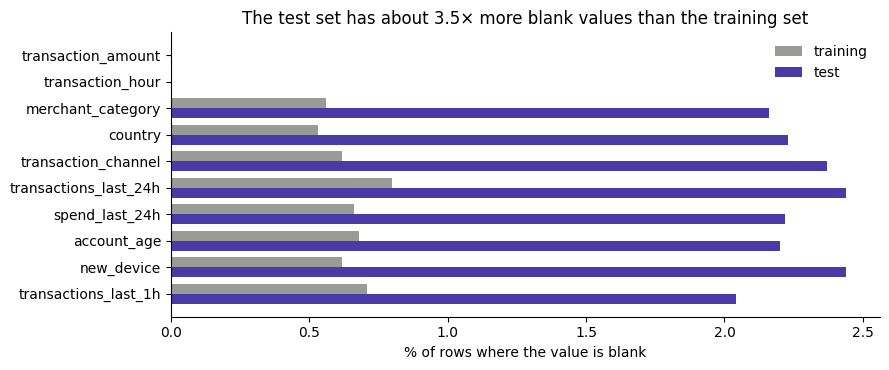

Average share of blanks per column: **0.52% in training vs 1.81% in test** (3.5×). `transaction_amount` and `transaction_hour` are never blank.

In [6]:
# 2.2 Size, blank values (training vs test) and the fraud rate
TRAIN_C, TEST_C = "#9a9a97", "#4a3aa7"            # fixed colours for training vs test in every chart
FEAT_COLS = [c for c in test.columns if c != ID_COL]
display(Markdown(f"**Training set:** {train.shape[0]:,} transactions × {train.shape[1]} columns (with the fraud label) · "
                 f"**Test set:** {test.shape[0]:,} transactions × {test.shape[1]} columns (label hidden) · "
                 f"**Fraud in training:** {int(train[TARGET].sum())} = {train[TARGET].mean():.2%}"))

overview = pd.DataFrame({
    "Kind of value": train[FEAT_COLS].dtypes.map(lambda d: "number" if d.kind in "fi" else "text"),
    "% of rows blank (training)": (train[FEAT_COLS].isna().mean() * 100).round(2),
    "% of rows blank (test)": (test[FEAT_COLS].isna().mean() * 100).round(2),
    "Number of different values (training)": train[FEAT_COLS].nunique(),
})
overview.index.name = "Column"
display(overview)

fig, ax = plt.subplots(figsize=(9, 3.8))
y = np.arange(len(FEAT_COLS)); h = 0.38
ax.barh(y - h / 2, overview["% of rows blank (training)"], h, color=TRAIN_C, label="training")
ax.barh(y + h / 2, overview["% of rows blank (test)"], h, color=TEST_C, label="test")
ax.set_yticks(y); ax.set_yticklabels(FEAT_COLS); ax.invert_yaxis()
ax.set_xlabel("% of rows where the value is blank"); ax.set_title("The test set has about 3.5× more blank values than the training set")
ax.legend(frameon=False); [ax.spines[s].set_visible(False) for s in ("top", "right")]
plt.tight_layout(); plt.show()

blank_tr = train[FEAT_COLS].isna().mean().mean() * 100; blank_te = test[FEAT_COLS].isna().mean().mean() * 100
display(Markdown(f"Average share of blanks per column: **{blank_tr:.2f}% in training vs {blank_te:.2f}% in test** "
                 f"({blank_te / blank_tr:.1f}×). `transaction_amount` and `transaction_hour` are never blank."))


**What we found**
- Training **20,000 × 12** (with the label); test **12,000 × 11**. `transaction_amount` and `transaction_hour` are never blank; every history column can be.
- Test is blank far more often: **1.81% vs 0.52%** of cells per column, **3.5×** the training rate.

**Implications:** the model will meet blanks far more often than while learning, so how we fill them is a design decision (Section 3.2).


### 2.3 Where does fraud concentrate?
Each panel shows the fraud rate within a group; the dashed line is the overall 1.76%. If fraud has a shape, Section 4 should be built around it.


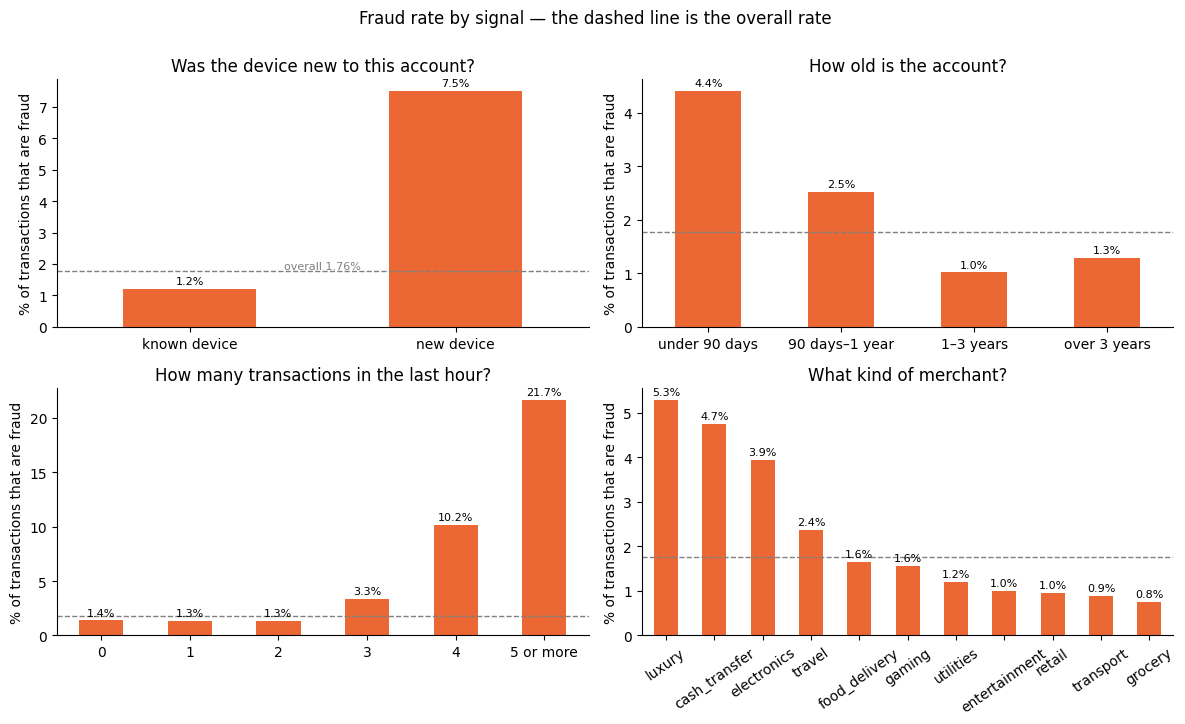


| Signal | Fraud rate | vs overall 1.76% |
|---|---|---|
| New device | **7.5%** (known device 1.2%) | 4.2× |
| Account under 90 days old | **4.4%** | 2.5× |
| 4 or more transactions in the last hour | **16.1%** | 9.1× |
| Riskiest merchants | **luxury 5.3%, cash_transfer 4.7%, electronics 3.9%** | up to 3.0× |


In [7]:
# 2.3 Fraud rate (% of transactions that are fraud) across the four strongest signals; dashed line = overall rate
base = 100 * train[TARGET].mean()
fig, axes = plt.subplots(2, 2, figsize=(12, 7.2))

r = train.groupby("new_device")[TARGET].mean().mul(100); r.index = ["known device", "new device"]
r.plot.bar(ax=axes[0, 0], color=FRAUD_C, rot=0); axes[0, 0].set_title("Was the device new to this account?")

age = pd.cut(train.account_age, [0, 90, 365, 1000, 4000], labels=["under 90 days", "90 days–1 year", "1–3 years", "over 3 years"])
train.groupby(age, observed=True)[TARGET].mean().mul(100).plot.bar(ax=axes[0, 1], color=FRAUD_C, rot=0)
axes[0, 1].set_title("How old is the account?")

r = train.groupby(train.transactions_last_1h.clip(upper=5))[TARGET].mean().mul(100); r.index = ["0", "1", "2", "3", "4", "5 or more"]
r.plot.bar(ax=axes[1, 0], color=FRAUD_C, rot=0); axes[1, 0].set_title("How many transactions in the last hour?")

train.groupby("merchant_category", observed=True)[TARGET].mean().mul(100).sort_values(ascending=False) \
     .plot.bar(ax=axes[1, 1], color=FRAUD_C, rot=35); axes[1, 1].set_title("What kind of merchant?")

for ax in axes.flat:
    ax.axhline(base, ls="--", c="gray", lw=1); ax.set_ylabel("% of transactions that are fraud"); ax.set_xlabel("")
    for s in ("top", "right"): ax.spines[s].set_visible(False)
    for bar in ax.patches: ax.annotate(f"{bar.get_height():.1f}%", (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                                       ha="center", va="bottom", fontsize=8, xytext=(0, 2), textcoords="offset points")
axes[0, 0].text(0.5, base, f"overall {base:.2f}%", ha="center", va="bottom", fontsize=8, color="gray")
plt.suptitle("Fraud rate by signal — the dashed line is the overall rate", y=1.0); plt.tight_layout(); plt.show()

nd = train.groupby("new_device")[TARGET].mean().mul(100)
young = 100 * train.loc[train.account_age < 90, TARGET].mean()
burst = 100 * train.loc[train.transactions_last_1h >= 4, TARGET].mean()
top_m = train.groupby("merchant_category")[TARGET].mean().mul(100).sort_values(ascending=False).head(3)
display(Markdown(f"""
| Signal | Fraud rate | vs overall {base:.2f}% |
|---|---|---|
| New device | **{nd[1]:.1f}%** (known device {nd[0]:.1f}%) | {nd[1] / base:.1f}× |
| Account under 90 days old | **{young:.1f}%** | {young / base:.1f}× |
| 4 or more transactions in the last hour | **{burst:.1f}%** | {burst / base:.1f}× |
| Riskiest merchants | **{", ".join(f"{k} {v:.1f}%" for k, v in top_m.items())}** | up to {top_m.iloc[0] / base:.1f}× |
"""))


**What we found**
- **New device 7.5%** vs 1.2% on a known device; **account under 90 days 4.4%**; **4+ transactions in the last hour 16.1%** (5+: 21.7%).
- Riskiest merchants **luxury 5.3%, cash transfer 4.7%, electronics 3.9%**; grocery and transport under 1%.

**Implications:** the classic account-takeover pattern — unfamiliar device, young account, a burst of activity, resellable goods or movable money — which is what the Section 4 features encode. A fraud showing none of these signs looks ordinary (Section 9).


### 2.4 Is the test set like the training set?
The model is judged on unseen data, and the private set "may contain different observations and edge cases", so we compare the sets and ask a classifier whether it can tell them apart.


,Training,Test,Test ÷ Training
Average transaction amount ($),252.66,523.93,2.07
"Share of transactions above 2,000 (%)",2.27,9.03,3.98
Share made from a new device (%),9.06,15.37,1.70
"Typical (median) account age, days",790.00,1158.00,1.47
Average share of blank values per column (%),0.52,1.81,3.48


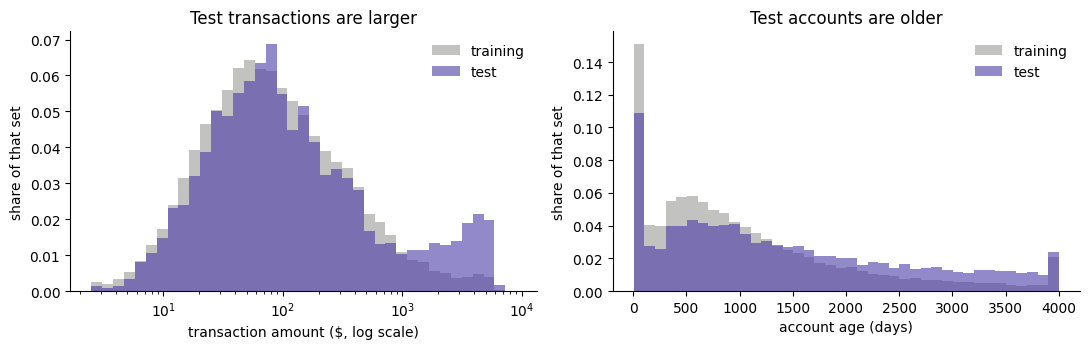

**Can a model tell training rows from test rows?** A classifier trained to do exactly that reaches **AUC 0.668** (0.5 would mean the two sets are indistinguishable). The columns it relies on most: **account_age, spend_last_24h, transaction_amount**.

**Test-like slice:** the 4,000 training rows most like the test set contain 136 frauds (3.40%, vs 1.76% overall).

In [8]:
# 2.4 Profile of training vs test, then a formal check: can a model tell the two sets apart?
def prof(df):
    return pd.Series({
        "Average transaction amount ($)": df.transaction_amount.mean(),
        "Share of transactions above 2,000 (%)": 100 * (df.transaction_amount > 2000).mean(),
        "Share made from a new device (%)": 100 * df.new_device.mean(),
        "Typical (median) account age, days": df.account_age.median(),
        "Average share of blank values per column (%)": 100 * df[FEAT_COLS].isna().mean().mean(),
    })
shift = pd.DataFrame({"Training": prof(train), "Test": prof(test)}).round(2)
shift["Test ÷ Training"] = (shift["Test"] / shift["Training"]).round(2)
display(shift)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
bins_amt = np.geomspace(train.transaction_amount.min(), train.transaction_amount.max(), 40)
for df, colour, label in [(train, TRAIN_C, "training"), (test, TEST_C, "test")]:
    axes[0].hist(df.transaction_amount, bins=bins_amt, weights=np.full(len(df), 1 / len(df)), alpha=0.6, color=colour, label=label)
    age_ = df.account_age.dropna()
    axes[1].hist(age_, bins=40, weights=np.full(len(age_), 1 / len(age_)), alpha=0.6, color=colour, label=label)
axes[0].set_xscale("log"); axes[0].set_xlabel("transaction amount ($, log scale)"); axes[0].set_title("Test transactions are larger")
axes[1].set_xlabel("account age (days)"); axes[1].set_title("Test accounts are older")
for ax in axes:
    ax.set_ylabel("share of that set"); ax.legend(frameon=False); [ax.spines[s].set_visible(False) for s in ("top", "right")]
plt.tight_layout(); plt.show()

# Adversarial validation: can a model tell train rows from test rows? AUC 0.5 = identical sets.
adv = pd.concat([train[FEAT_COLS], test[FEAT_COLS]], ignore_index=True)
for c in adv.select_dtypes("object"):
    adv[c] = adv[c].astype("category")
is_test = pd.Series(np.r_[np.zeros(len(train)), np.ones(len(test))])
aucs, p_adv = [], np.zeros(len(adv))
for tr_idx, va_idx in StratifiedKFold(3, shuffle=True, random_state=RANDOM_STATE).split(adv, is_test):
    m = lgb.LGBMClassifier(n_estimators=100, learning_rate=0.1, num_leaves=15,
                           random_state=RANDOM_STATE, verbose=-1).fit(adv.iloc[tr_idx], is_test.iloc[tr_idx])
    p_adv[va_idx] = m.predict_proba(adv.iloc[va_idx])[:, 1]
    aucs.append(roc_auc_score(is_test.iloc[va_idx], p_adv[va_idx]))
imp = pd.Series(m.feature_importances_, index=adv.columns).sort_values(ascending=False)
display(Markdown(f"**Can a model tell training rows from test rows?** A classifier trained to do exactly that reaches "
                 f"**AUC {np.mean(aucs):.3f}** (0.5 would mean the two sets are indistinguishable). "
                 f"The columns it relies on most: **{', '.join(imp.index[:3])}**."))

# "Test-like" slice: the 20% of TRAINING rows that most resemble the test set. Every model is also scored on this slice (Sections 5 and 7),
# because the private test set looks more like it than like the average training row.
adv_p_train = p_adv[:len(train)]
TEST_LIKE = adv_p_train >= np.quantile(adv_p_train, 0.80)
display(Markdown(f"**Test-like slice:** the {TEST_LIKE.sum():,} training rows most like the test set contain "
                 f"{int(train.loc[TEST_LIKE, TARGET].sum())} frauds ({train.loc[TEST_LIKE, TARGET].mean():.2%}, vs {train[TARGET].mean():.2%} overall)."))


**What we found**
- Test transactions are larger (average **\$523.93 vs \$252.66**; **9.03% vs 2.27%** above 2,000), accounts older (median **1,158 vs 790 days**), new devices more common (**15.4% vs 9.1%**).
- A classifier separates the sets with **AUC 0.668** (0.5 = identical), using account age, 24-hour spend and amount.
- The **test-like slice** (4,000 most test-like training rows) holds **136 frauds, 3.40%**, nearly twice the overall rate.

**Implications:** we optimise for robustness, not the public leaderboard: deliberate blank-filling (Section 3.2), a feature that separates large purchases on long-standing accounts from large purchases on new ones (Section 4), and scoring every model on the test-like slice and under injected blanks (Sections 5–7).


### 2.5 Where could the data mislead the model?
An artefact of how the data was produced is a trap: a model learns it and fails on the test set. The obvious candidate is rows with blank values.


,Rows where it is blank,Frauds among those rows,Fraud rate when blank (%),Fraud rate when filled in (%)
Column,,,,
merchant_category,113,0,0.00,1.78
country,107,1,0.93,1.77
transaction_channel,123,4,3.25,1.76
transactions_last_24h,159,5,3.14,1.75
spend_last_24h,132,4,3.03,1.76
account_age,137,3,2.19,1.76
new_device,124,0,0.00,1.78
transactions_last_1h,142,4,2.82,1.76


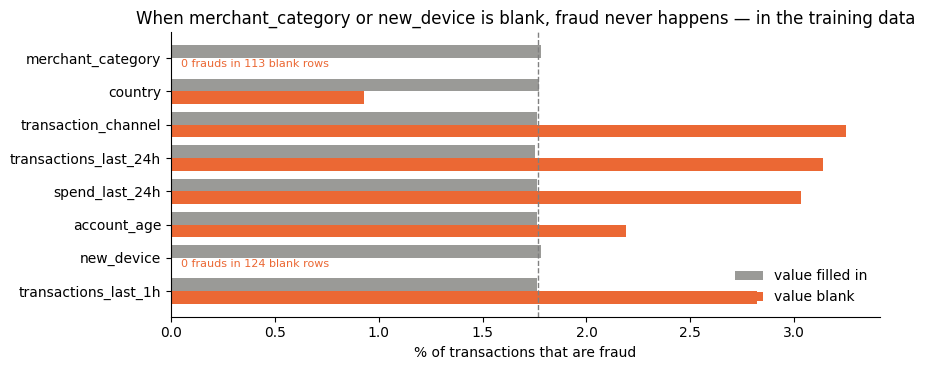

In [9]:
# 2.5 Fraud rate when a column is blank vs when it is filled in
rows = []
for c in FEAT_COLS:
    miss = train[c].isna()
    if miss.any():
        rows.append({"Column": c, "Rows where it is blank": int(miss.sum()),
                     "Frauds among those rows": int(train.loc[miss, TARGET].sum()),
                     "Fraud rate when blank (%)": round(100 * train.loc[miss, TARGET].mean(), 2),
                     "Fraud rate when filled in (%)": round(100 * train.loc[~miss, TARGET].mean(), 2)})
blanks = pd.DataFrame(rows).set_index("Column")
display(blanks)

fig, ax = plt.subplots(figsize=(9, 3.8))
y = np.arange(len(blanks)); h = 0.38
ax.barh(y - h / 2, blanks["Fraud rate when filled in (%)"], h, color="#9a9a97", label="value filled in")
ax.barh(y + h / 2, blanks["Fraud rate when blank (%)"], h, color=FRAUD_C, label="value blank")
for yi, (name, row) in zip(y, blanks.iterrows()):
    if row["Frauds among those rows"] == 0:
        ax.text(0.05, yi + h / 2, f"0 frauds in {int(row['Rows where it is blank'])} blank rows", va="center", fontsize=8, color=FRAUD_C)
ax.axvline(100 * train[TARGET].mean(), ls="--", c="gray", lw=1)
ax.set_yticks(y); ax.set_yticklabels(blanks.index); ax.invert_yaxis()
ax.set_xlabel("% of transactions that are fraud"); ax.set_title("When merchant_category or new_device is blank, fraud never happens — in the training data")
ax.legend(frameon=False, loc="lower right"); [ax.spines[s].set_visible(False) for s in ("top", "right")]
plt.tight_layout(); plt.show()


**What we found**
- A blank `merchant_category` is **never** fraud (**0 of 113**); a blank `new_device` is **never** fraud (**0 of 124**). Other blank columns run 2–3%, above the 1.76% overall.

**Implications:** zero frauds in 237 rows is too clean to be real. Left alone, the model learns "blank means safe" and waves through exactly the rows the test set has 3.5× more of; Section 3.2 neutralises it.


## 3. Clean the data
Check nothing is broken, then fill blanks without teaching the model the false pattern from Section 2.5. Everything is hard-coded from the training set so it runs identically on the test file alone.


### 3.1 Is anything broken?
We assert the basics: unique IDs, no duplicate rows, hours 0–23, positive amounts, 1-hour count never above the 24-hour count.


In [10]:
# 3.1 Quality checks - all must pass before we transform anything.
assert train[ID_COL].is_unique and test[ID_COL].is_unique
assert train.drop(columns=ID_COL).duplicated().sum() == 0
for df in (train, test):
    assert df.transaction_hour.between(0, 23).all()
    assert (df.transaction_amount > 0).all() and df.transaction_amount.notna().all()
    both = df[["transactions_last_1h", "transactions_last_24h"]].dropna()
    assert (both.transactions_last_1h <= both.transactions_last_24h).all()
quirk_tr = ((train.transactions_last_24h == 1) & (train.spend_last_24h > 0)).sum()
quirk_te = ((test.transactions_last_24h == 1) & (test.spend_last_24h > 0)).sum()
print(f"all quality checks passed | spend-definition quirk rows (txns_24h==1 & spend>0): train {quirk_tr}, test {quirk_te}")


all quality checks passed | spend-definition quirk rows (txns_24h==1 & spend>0): train 234, test 762


**What we found**
- All checks pass. One quirk: **234 training / 762 test rows** show one transaction in 24 hours but spend above zero, so the spend window is inconsistently defined; we guard the ratio features rather than "fix" it.

**Implications:** the data is clean enough to trust; the only real risk is the blank-value artefact, handled next.


### 3.2 How do we fill blank values, and why?
Every blank becomes a fixed training value (median for numbers, most common value for categories), with **no "was blank" flag**; constants are hard-coded so the prediction notebook reproduces them without `train.csv`. A category never seen in training becomes `"unknown"` without crashing.


In [11]:
# 3.2 clean(): impute with train constants (hard-coded so prediction.ipynb reproduces them
# without train.csv), then fix category vocabularies. Constants are verified against train below.
MERCHANTS = ["cash_transfer", "electronics", "entertainment", "food_delivery", "gaming",
             "grocery", "luxury", "retail", "transport", "travel", "utilities"]
COUNTRIES = ["AU", "GB", "ID", "JP", "MY", "PH", "SG", "TH", "US", "VN"]
CHANNELS  = ["bank_transfer", "card_present", "ecommerce", "mobile_app"]
CAT_VOCAB = {"merchant_category": MERCHANTS, "country": COUNTRIES, "transaction_channel": CHANNELS}
IMPUTE = {"transactions_last_24h": 4.0, "spend_last_24h": 217.515, "account_age": 790.0,
          "new_device": 0.0, "transactions_last_1h": 1.0,
          "merchant_category": "grocery", "country": "SG", "transaction_channel": "card_present"}

# Training ranges (min, max). Every numeric is clipped to its range so an out-of-range private-test
# value can neither crash the pipeline (a negative amount makes log1p NaN) nor be extrapolated by the
# linear model (transactions_last_24h = 100 would otherwise score 0.99). No training row is changed.
IMPUTE_AMOUNT, IMPUTE_HOUR = 75.125, 11                 # train medians, for the two never-blank columns
RANGES = {"transaction_amount": (2.5, 9000.0), "transaction_hour": (0, 23), "transactions_last_24h": (1, 27),
          "spend_last_24h": (0.0, 15670.31), "account_age": (5, 4000), "new_device": (0, 1), "transactions_last_1h": (0, 9)}

def clean(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    for c, v in IMPUTE.items():                             # blanks -> typical value (see 3. above)
        out[c] = out[c].fillna(v)
    for c, vocab in CAT_VOCAB.items():
        out[c] = pd.Categorical(out[c], categories=vocab)   # unseen category -> NaN, never a crash
    return out

# Guard against drift: the hard-coded constants must equal what train actually says.
for c, v in IMPUTE.items():
    ref = train[c].mode()[0] if train[c].dtype == object else float(train[c].median())
    assert ref == v or abs(ref - v) < 1e-6, f"IMPUTE drift on {c}: train says {ref}, hard-coded {v}"
assert clean(train)[list(IMPUTE)].isna().sum().sum() == 0
assert clean(test)[list(IMPUTE)].isna().sum().sum() == 0
print("clean() OK - imputation constants match train; no blanks remain in either set")


clean() OK - imputation constants match train; no blanks remain in either set


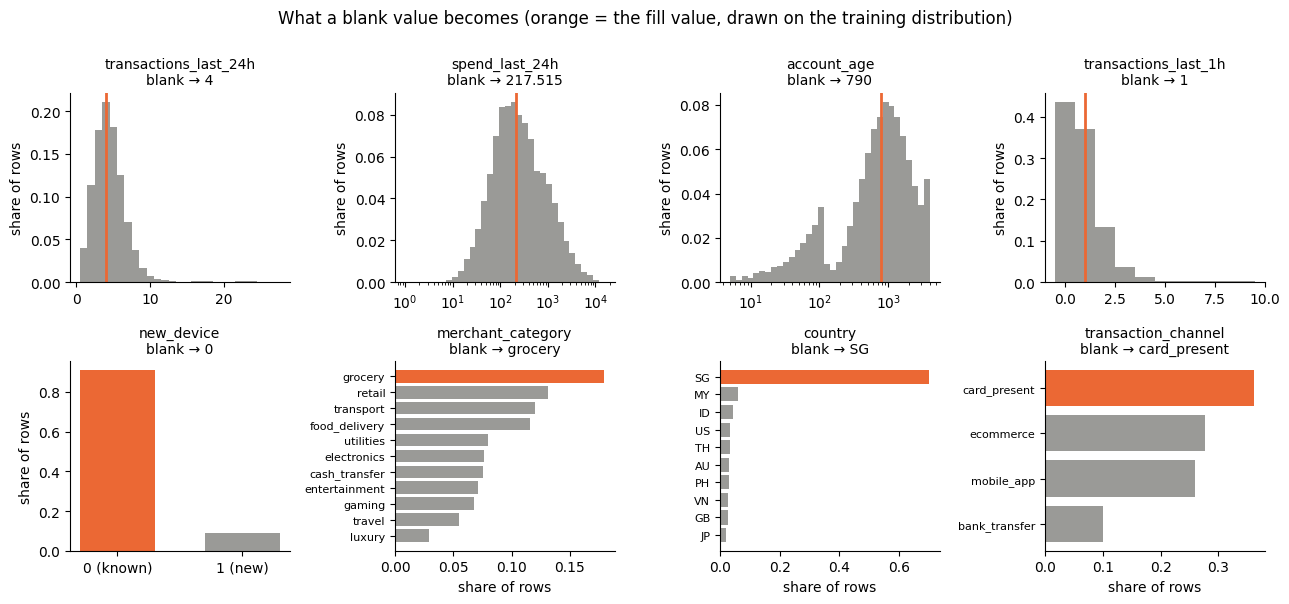

,Fill value for a blank,Why this value
Column,,
transactions_last_24h,4.0,median
spend_last_24h,217.515,median
account_age,790.0,median
transactions_last_1h,1.0,median
new_device,0.0,most common value (0 = known device)
merchant_category,grocery,most common category
country,SG,most common category
transaction_channel,card_present,most common category


In [12]:
# 3.2 Where the fill values sit: a blank becomes a typical value, not an extreme one
num_cols = ["transactions_last_24h", "spend_last_24h", "account_age", "transactions_last_1h", "new_device"]
cat_cols = ["merchant_category", "country", "transaction_channel"]
fig, axes = plt.subplots(2, 4, figsize=(13, 6)); axes = list(axes.flat)
for ax, col in zip(axes[:5], num_cols):
    vals = train[col].dropna(); fill = IMPUTE[col]
    if col == "new_device":
        share = vals.value_counts(normalize=True).sort_index()
        ax.bar(["0 (known)", "1 (new)"], share.values, color=[TRAIN_C if v != fill else FRAUD_C for v in share.index], width=0.6)
        ax.set_ylabel("share of rows")
    else:
        bins = np.geomspace(max(vals.min(), 1), vals.max(), 35) if col in ("spend_last_24h", "account_age") else np.arange(vals.min(), vals.max() + 2) - 0.5
        ax.hist(vals, bins=bins, weights=np.full(len(vals), 1 / len(vals)), color=TRAIN_C)
        if col in ("spend_last_24h", "account_age"): ax.set_xscale("log")
        ax.axvline(fill, color=FRAUD_C, lw=2); ax.set_ylabel("share of rows")
    ax.set_title(f"{col}\nblank → {fill:g}", fontsize=10); [ax.spines[s].set_visible(False) for s in ("top", "right")]
for ax, col in zip(axes[5:8], cat_cols):
    share = train[col].value_counts(normalize=True)
    ax.barh(share.index[::-1], share.values[::-1], color=[FRAUD_C if k == IMPUTE[col] else TRAIN_C for k in share.index[::-1]])
    ax.set_title(f"{col}\nblank → {IMPUTE[col]}", fontsize=10); ax.set_xlabel("share of rows"); ax.tick_params(axis="y", labelsize=8)
    [ax.spines[s].set_visible(False) for s in ("top", "right")]
plt.suptitle("What a blank value becomes (orange = the fill value, drawn on the training distribution)", y=1.0)
plt.tight_layout(); plt.show()

fills = pd.DataFrame({"Fill value for a blank": [IMPUTE[c] for c in num_cols + cat_cols],
                      "Why this value": ["median"] * 4 + ["most common value (0 = known device)"] + ["most common category"] * 3},
                     index=num_cols + cat_cols); fills.index.name = "Column"
display(fills)
# Takeaway: every fill value sits in the thick middle of its column's distribution, so an imputed row is indistinguishable from an ordinary one.


**What we found**
- Numeric blanks become the training median (e.g. 4 transactions in 24 hours, \$217.52 spend, 790 days of account age); a blank device flag becomes 0 (known device); blank categories become the most common one (grocery, SG, card present).
- Every fill value sits in the thick middle of its column's distribution (orange marks), and the assertion above confirms no blanks remain in either set.

**Implications:** an imputed row is indistinguishable from an ordinary row, so the model cannot learn "blank means safe". The proof that this works is in Section 7.2: rows that were originally blank score 0.0109 on average against 0.0177 for all rows — normal, not near zero. The assumption is that blanks are recording gaps, not fraudster behaviour; if the private set's blanks genuinely signalled fraud we would lose that signal, an acceptable loss since it does not exist in training.


## 4. Build features the model can use
`make_features(df)` turns the 10 raw columns into **29 features**; it applies the Section 3.2 constants itself and clips every number to its training range, so an extreme value in the private set can neither crash the pipeline nor be extrapolated. In plain terms:

| Group | Features | What they capture |
|---|---|---|
| Scale | log of amount, account age, 24-hour spend | large values count in proportion |
| Context | amount ÷ today's spend, amount vs usual transaction, amount relative to account age, spend per transaction | is *this* purchase unusual for *this* account today? |
| Velocity | transactions in last hour / today, burst ratio, ≥3 and ≥4 in the last hour, ≥10 today | the bursts that mark account takeover |
| Time | hour, night flag, hour as sine/cosine | late-night activity |
| Thresholds | amount > 500, account < 180 days | where the fraud rate jumps (Section 2.3) |
| Interactions | new device × young account, new device × night, amount × new device, amount × night, burst × young account | the combinations that multiply risk |
| Tempering signal | large purchase on an account over 1,000 days old | a large purchase on a long-standing account is far less risky than one on a new account — keeps the test set's many large, old-account purchases from being over-flagged |


### 4.1 What does the model see?
Both the raw 10 columns (for the Section 5 baseline) and the 29-feature matrix (for Section 6).


In [13]:
RAW_FEATURES = ["transaction_amount", "transaction_hour", "merchant_category", "country",
                "transaction_channel", "transactions_last_24h", "spend_last_24h",
                "account_age", "new_device", "transactions_last_1h"]
NUMS = ["log_amount", "log_age", "log_spend", "transactions_last_1h", "transactions_last_24h",
        "transaction_hour", "amt_share_24h", "amt_vs_prev_avg", "log_amt_per_age", "burst_ratio",
        "log_amt_x_newdev", "log_amt_x_night", "hour_sin", "hour_cos", "spend_per_txn"]
FLAGS = ["new_device", "night", "amt_gt500", "age_lt180", "n1_ge3", "n1_ge4", "n24_ge10",
         "newdev_young", "big_old", "night_newdev", "burst_young"]
FEATURES = list(CAT_VOCAB) + NUMS + FLAGS         # 3 categoricals + 15 numerics + 11 flags = 29

def make_features(df: pd.DataFrame) -> pd.DataFrame:
    """v2 features (inlined from src/models.py). Runs on the raw test csv alone; never uses id."""
    d = df.copy()
    for c, v in IMPUTE.items():                       # blanks -> train constants (same policy as Section 3)
        d[c] = (pd.to_numeric(d[c], errors="coerce") if c not in CAT_VOCAB else d[c]).fillna(v)
    d["transaction_amount"] = pd.to_numeric(d["transaction_amount"], errors="coerce").fillna(IMPUTE_AMOUNT)
    d["transaction_hour"] = pd.to_numeric(d["transaction_hour"], errors="coerce").fillna(IMPUTE_HOUR)
    for c, (lo, hi) in RANGES.items():                 # out-of-range -> training range (see RANGES)
        d[c] = d[c].clip(lo, hi)
    for c in CAT_VOCAB:                               # unseen category -> "unknown": all-zero one-hot
        d[c] = d[c].where(d[c].isin(CAT_VOCAB[c]), "unknown")
    a, s, age = d.transaction_amount.astype(float), d.spend_last_24h, d.account_age
    n1, n24, nd, hr = d.transactions_last_1h, d.transactions_last_24h, d.new_device, d.transaction_hour
    X = d[list(CAT_VOCAB)].copy()
    X["log_amount"] = np.log1p(a)
    X["log_age"] = np.log1p(age)
    X["log_spend"] = np.log1p(s)
    X["transactions_last_1h"] = n1
    X["transactions_last_24h"] = n24
    X["transaction_hour"] = hr
    X["amt_share_24h"] = a / (a + s)                                        # this txn vs the day's spend
    X["amt_vs_prev_avg"] = np.log1p(a) - np.log1p(s / np.maximum(n24 - 1, 1))  # vs avg previous txn
    X["log_amt_per_age"] = np.log1p(a) - np.log1p(age)                      # big amount, young account
    X["burst_ratio"] = n1 / np.maximum(n24, 1)
    X["new_device"] = nd
    X["night"] = (hr <= 5).astype(float)
    X["amt_gt500"] = (a > 500).astype(float)                                # fraud 5-6% above $500
    X["age_lt180"] = (age < 180).astype(float)
    X["n1_ge3"] = (n1 >= 3).astype(float)
    X["n1_ge4"] = (n1 >= 4).astype(float)
    X["n24_ge10"] = (n24 >= 10).astype(float)
    X["newdev_young"] = nd * (age < 180)                                    # 17% fraud in train
    X["big_old"] = ((a > 500) & (age > 1000)).astype(float)                 # loyal big spender: NOT fraud
    X["log_amt_x_newdev"] = X["log_amount"] * nd
    X["log_amt_x_night"] = X["log_amount"] * X["night"]
    X["hour_sin"] = np.sin(2 * np.pi * hr / 24)
    X["hour_cos"] = np.cos(2 * np.pi * hr / 24)
    X["spend_per_txn"] = np.log1p(s / np.maximum(n24, 1))
    X["night_newdev"] = X["night"] * nd
    X["burst_young"] = X["n1_ge3"] * (age < 365).astype(float)
    return X[FEATURES]

y = train[TARGET]
X_raw = clean(train)[RAW_FEATURES]     # 10 raw columns - the Section 5.1 baseline and Section 5.2 lesson use these
X = make_features(train)               # v2 - everything from Section 6 on uses these
print(f"X_raw {X_raw.shape} | X {X.shape}")


X_raw (20000, 10) | X (20000, 29)


,Rows with flag on,Fraud rate when on (%),Fraud rate when off (%)
Flag,,,
new device,1800,7.5,1.2
night-time (0–5h),5090,2.3,1.6
amount > 500,2129,5.7,1.3
account < 180 days,3683,4.2,1.2
≥3 transactions in the last hour,1187,8.3,1.4
≥4 transactions in the last hour,466,16.1,1.4
≥10 transactions today,515,15.1,1.4
new device × young account,534,17.2,1.3
new device × night,400,14.8,1.5


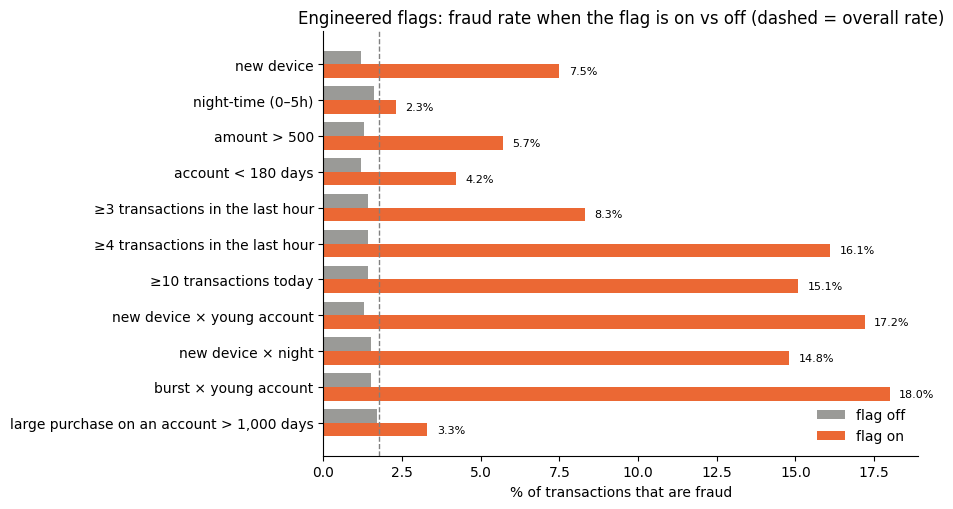

In [14]:
# 4.1 Fraud rate when each engineered flag is on vs off (computed from X, no model involved)
flag_cols = {"new_device": "new device", "night": "night-time (0–5h)", "amt_gt500": "amount > 500", "age_lt180": "account < 180 days",
             "n1_ge3": "≥3 transactions in the last hour", "n1_ge4": "≥4 transactions in the last hour", "n24_ge10": "≥10 transactions today",
             "newdev_young": "new device × young account", "night_newdev": "new device × night", "burst_young": "burst × young account",
             "big_old": "large purchase on an account > 1,000 days"}
rows = []
for col, label in flag_cols.items():
    on = X[col] >= 0.5
    rows.append({"Flag": label, "Rows with flag on": int(on.sum()),
                 "Fraud rate when on (%)": round(100 * y[on].mean(), 1), "Fraud rate when off (%)": round(100 * y[~on].mean(), 1)})
flags_tbl = pd.DataFrame(rows).set_index("Flag")
display(flags_tbl)

fig, ax = plt.subplots(figsize=(9.5, 5.2))
yy = np.arange(len(flags_tbl)); h = 0.38
ax.barh(yy - h / 2, flags_tbl["Fraud rate when off (%)"], h, color=TRAIN_C, label="flag off")
ax.barh(yy + h / 2, flags_tbl["Fraud rate when on (%)"], h, color=FRAUD_C, label="flag on")
for yi, v in zip(yy, flags_tbl["Fraud rate when on (%)"]): ax.text(v + 0.3, yi + h / 2, f"{v:.1f}%", va="center", fontsize=8)
ax.axvline(100 * y.mean(), ls="--", c="gray", lw=1)
ax.set_yticks(yy); ax.set_yticklabels(flags_tbl.index); ax.invert_yaxis()
ax.set_xlabel("% of transactions that are fraud"); ax.set_title("Engineered flags: fraud rate when the flag is on vs off (dashed = overall rate)")
ax.legend(frameon=False, loc="lower right"); [ax.spines[s].set_visible(False) for s in ("top", "right")]
plt.tight_layout(); plt.show()
# Takeaway: the interaction flags concentrate fraud far more than single signals; a large purchase on an old account is
# much less risky than a large purchase in general (compare with the amount > 500 row), which is what the flag is for.


**What we found**
- Raw matrix **20,000 × 10**; engineered matrix **20,000 × 29**; no blanks.
- The interaction flags concentrate fraud most: **burst × young account 18.0%**, **new device × young account 17.2%**, **≥4 transactions in the last hour 16.1%**, **≥10 today 15.1%**, against 1.76% overall — far above any single signal (new device 7.5%, amount > 500 5.7%).
- A large purchase on an account over 1,000 days old runs **3.3%**, well below the 5.7% of large purchases in general: the flag lets the model tell a loyal big spender from a risky one.

**Implications:** the features are the Section 2.3 findings made explicit — the combinations that multiply risk and the one that tempers it. A tree finds such interactions by splitting, so they add little for LightGBM (Section 5.2); a linear model cannot, so for logistic regression they *are* the gain (Section 6).


## 5. Start with a baseline
Before building anything clever, we set two baselines to compare against:

1. **Guessing:** give every row the overall positive rate and ignore the data (base rate). Any useful model must beat this.
2. **Quick LightGBM:** a strong off-the-shelf model with near-default settings, trained on the data as-is (untuned LightGBM on raw columns). Later work should beat this, or it isn't worth the effort.

**How every model in this notebook is scored**
- Split the data into 5 parts. Train on 4, test on the 5th, and rotate so each part gets tested once (5-fold cross-validation).
- Each part keeps the same share of positives as the full dataset (stratified).
- Repeat this 3 times with different shuffles, for 15 scores in total (repeated 3×5 cross-validation).
- Report the **average score ± how much it varies** (mean ± standard deviation), and how many times better than guessing it is (lift over the base rate).

**Saved for later:** each row gets a prediction from a model that never saw it during training (out-of-fold predictions). These are an honest preview of performance on new data, and we reuse them in Section 7.


### 5.1 How good is a simple model?
If a quick, simple model already does about as well as the data allows (the ceiling), extra complexity isn't worth it. So we measure it first.

**How we score:** not by "% correct" (accuracy). Fraud is so rare that a model saying "not fraud" every time would be 98% correct but catch nothing. Instead we check how well the model puts the real fraud cases at the top of its suspicion list (PR-AUC). Guessing scores about 0.018; a perfect model scores 1.0. In the table, the guessing row's "best cut-off" is to flag everything, which is why it shows 100% recall with almost every flag a false alarm. The table's ranking score is computed on all rows pooled together; the headline number printed above it is the average over the 15 test chunks.


In [15]:
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def fold_scores(model_fn, X, y, n_splits=5, n_repeats=3):
    """Per-fold PR-AUC over repeated stratified CV, plus pooled OOF probabilities (first repeat)."""
    rskf = RepeatedStratifiedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=RANDOM_STATE)
    aps, oof = [], np.zeros(len(y), dtype=float)
    for i, (tr_idx, va_idx) in enumerate(rskf.split(X, y)):
        m = model_fn()
        m.fit(X.iloc[tr_idx], y.iloc[tr_idx])
        p = m.predict_proba(X.iloc[va_idx])[:, 1]
        aps.append(average_precision_score(y.iloc[va_idx], p))
        if i < n_splits:
            oof[va_idx] = p
    return np.array(aps), oof

def evaluate(y_true, p, name=""):
    prec, rec, thr = precision_recall_curve(y_true, p)
    f1s = 2 * prec * rec / np.clip(prec + rec, 1e-9, None)
    k = int(np.nanargmax(f1s[:-1]))
    return {"model": name, "PR-AUC": round(average_precision_score(y_true, p), 4),
            "ROC-AUC": round(roc_auc_score(y_true, p), 4),
            "best_F1": round(float(f1s[k]), 4), "recall@bestF1": round(float(rec[k]), 4),
            "precision@bestF1": round(float(prec[k]), 4),
            "threshold@bestF1": round(float(thr[k]), 4),
            "Brier": round(brier_score_loss(y_true, p), 5)}

def lgbm_baseline():
    return lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=15,
                              random_state=RANDOM_STATE, verbose=-1)

BASE_RATE = y.mean()
naive = np.full(len(y), BASE_RATE)
aps_base, oof_base = fold_scores(lgbm_baseline, X_raw, y)
print(f"LightGBM baseline PR-AUC (3x5 CV): {aps_base.mean():.4f} ± {aps_base.std():.4f}"
      f"  = {aps_base.mean() / BASE_RATE:.1f}x lift over the {BASE_RATE:.4f} base rate")
PLAIN_COLS = {"model": "Model", "PR-AUC": "Ranking score (PR-AUC, pooled)", "best_F1": "Best F1",
              "recall@bestF1": "Fraud caught (recall)", "precision@bestF1": "Flags that are real (precision)",
              "threshold@bestF1": "Cut-off (threshold)", "Brier": "Probability error (Brier, lower = better)"}
tbl = pd.DataFrame([evaluate(y, naive, "Guessing (base rate)"),
                    evaluate(y, oof_base, "LightGBM baseline")])
tbl.drop(columns="ROC-AUC").rename(columns=PLAIN_COLS)


LightGBM baseline PR-AUC (3x5 CV): 0.1952 ± 0.0448  = 11.1x lift over the 0.0176 base rate


,Model,"Ranking score (PR-AUC, pooled)",Best F1,Fraud caught (recall),Flags that are real (precision),Cut-off (threshold),"Probability error (Brier, lower = better)"
0,Guessing (base rate),0.0176,0.0347,1.0000,0.0176,0.0176,0.01734
1,LightGBM baseline,0.1864,0.2660,0.2125,0.3555,0.1636,0.01571


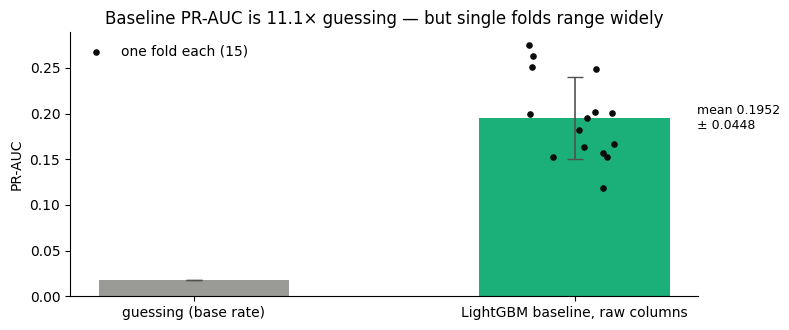

Fold scores range from **0.1182** to **0.2753** (mean 0.1952, spread ± 0.0448).

In [16]:
# 5.1 The baseline's 15 fold scores vs guessing: the spread between folds is the noise every later comparison must beat
MODEL_C = "#1baf7a"                                       # fixed colour for model scores in every chart from here on
fig, ax = plt.subplots(figsize=(8, 3.4))
ax.bar(["guessing (base rate)", "LightGBM baseline, raw columns"], [BASE_RATE, aps_base.mean()], color=[TRAIN_C, MODEL_C], width=0.5,
       yerr=[0, aps_base.std()], capsize=6, error_kw=dict(lw=1.2, ecolor="#52514e"))
jitter = np.random.default_rng(0).uniform(-0.12, 0.12, len(aps_base))
ax.scatter(1 + jitter, aps_base, color="#0b0b0b", s=14, zorder=3, label="one fold each (15)")
ax.text(1.3, aps_base.mean(), f"  mean {aps_base.mean():.4f}\n  ± {aps_base.std():.4f}", va="center", fontsize=9)
ax.set_ylabel("PR-AUC"); ax.set_title(f"Baseline PR-AUC is {aps_base.mean() / BASE_RATE:.1f}× guessing — but single folds range widely")
ax.legend(frameon=False, loc="upper left"); [ax.spines[s].set_visible(False) for s in ("top", "right")]
plt.tight_layout(); plt.show()
display(Markdown(f"Fold scores range from **{aps_base.min():.4f}** to **{aps_base.max():.4f}** (mean {aps_base.mean():.4f}, spread ± {aps_base.std():.4f})."))
# Takeaway: a single train/validation split could land anywhere in that range, which is why every score in this notebook is a mean over folds.


**What we found**
- **Fraud is rare:** only about 18 in every 1,000 transactions (base rate 1.8%).
- **The simple model works:** it's about **11× better than random guessing** at putting fraud cases at the top of its suspicion list (PR-AUC 0.195 vs 0.018). So the data does contain useful clues.
- **But the score jumps around a lot.** We tested it 15 times on different chunks of the data, and the score ranged from 0.118 to 0.275 (fold-to-fold variance). Because fraud is so rare, each chunk has only a handful of fraud cases, so luck plays a big part.
- **As a fraud alarm:** if we flag every transaction the model rates above 16% (threshold), it catches about **1 in 5** fraud cases (recall 0.21), and about **1 in 3** alarms are real fraud (precision 0.36).
- **Its % estimates aren't much better than a flat guess.** The model is good at saying which transactions are *more* suspicious than others, but its actual percentages are only slightly more accurate than saying "1.8%" for everyone (Brier score 0.0157 vs 0.0173).

**Implications:** one test alone could give almost any score in that range, so we always average all 15. From here on, a new model only counts as better if it beats this one **on the same chunks of data, again and again** (paired comparison), not just by a lucky higher average.


### 5.2 Do hand-made features help a tree model?
We tried 8 new columns built from existing ones (feature engineering), for example "is the transaction at night?" or "amount compared to the last 24h of spending". Each was added to the baseline **one at a time**.

A feature is kept only if:
- it improves the score by **more than the normal variation** between folds (paired gain > one standard deviation), and
- it doesn't hurt the score on the part of the training data that looks most like the test set (test-like slice).


In [17]:
cl = clean(train)
CANDIDATES = {
    "is_night":           cl.transaction_hour.isin(range(6)).astype(int),
    "log_amount":         np.log1p(cl.transaction_amount),
    "amount_cents":       (cl.transaction_amount * 100 % 100).round(),
    "amount_per_spend24": cl.transaction_amount / (cl.spend_last_24h + 1),
    "amount_per_age":     cl.transaction_amount / (cl.account_age + 1),
    "burst_ratio":        cl.transactions_last_1h / cl.transactions_last_24h,
    "new_device_young":   (cl.new_device * (cl.account_age < 180)).astype(float),
    "spend_per_txn":      cl.spend_last_24h / cl.transactions_last_24h,
}
rows = []
for name, col in CANDIDATES.items():
    Xf = X_raw.copy(); Xf[name] = col
    aps_f, oof_f = fold_scores(lgbm_baseline, Xf, y)
    d = aps_f - aps_base
    d_slice = (average_precision_score(y[TEST_LIKE], oof_f[TEST_LIKE])
               - average_precision_score(y[TEST_LIKE], oof_base[TEST_LIKE]))
    rows.append({"feature": name, "dPR-AUC": round(d.mean(), 4), "std": round(d.std(), 4),
                 "d_test_like": round(d_slice, 4), "keep": bool(d.mean() > d.std() and d_slice >= -0.01)})
pd.DataFrame(rows)
# Takeaway: no candidate clears the bar FOR LIGHTGBM - log transforms are no-ops for trees and the
# ratios are splits it already finds. The lesson (see Section 4): the same features are a +0.016 PR-AUC gain
# for logistic regression, which needs them spelled out - test features per model family, not in general.


,feature,dPR-AUC,std,d_test_like,keep
0,is_night,-0.0018,0.0085,-0.0071,False
1,log_amount,0.0000,0.0000,0.0000,False
2,amount_cents,-0.0057,0.0178,-0.0163,False
3,amount_per_spend24,-0.0008,0.0184,-0.0000,False
4,amount_per_age,-0.0054,0.0127,0.0005,False
5,burst_ratio,-0.0030,0.0114,-0.0061,False
6,new_device_young,-0.0057,0.0131,-0.0133,False
7,spend_per_txn,-0.0028,0.0149,-0.0000,False


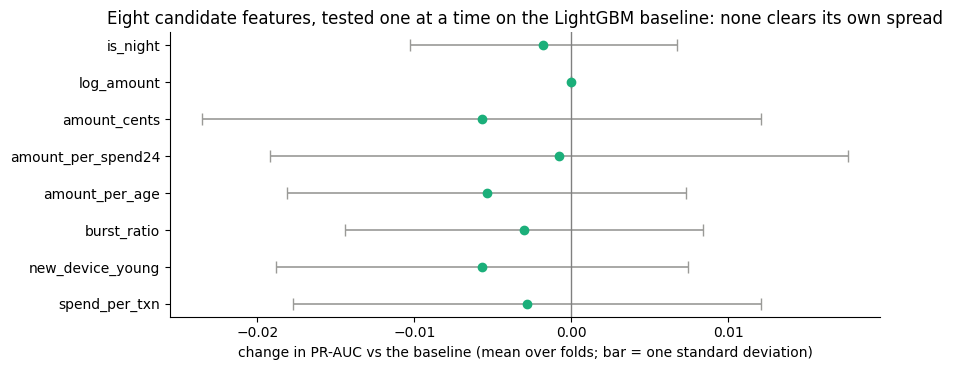

Largest gain: **+0.0000** (log_amount); largest loss: **-0.0057** (amount_cents); features kept: **0 of 8**.

In [18]:
# 5.2 Each candidate feature's paired gain in PR-AUC (dot) with its spread across folds (bar); keep-rule = gain beyond the spread
feat_tbl = pd.DataFrame(rows).set_index("feature")        # `rows` here is the 5.2 table above (Section 6 reuses the name later)
fig, ax = plt.subplots(figsize=(9, 3.8))
yy = np.arange(len(feat_tbl))
ax.errorbar(feat_tbl["dPR-AUC"], yy, xerr=feat_tbl["std"], fmt="o", color=MODEL_C, ecolor="#9a9a97", capsize=4, lw=1.2)
ax.axvline(0, color="gray", lw=1)
ax.set_yticks(yy); ax.set_yticklabels(feat_tbl.index); ax.invert_yaxis()
ax.set_xlabel("change in PR-AUC vs the baseline (mean over folds; bar = one standard deviation)")
ax.set_title("Eight candidate features, tested one at a time on the LightGBM baseline: none clears its own spread")
[ax.spines[s].set_visible(False) for s in ("top", "right")]
plt.tight_layout(); plt.show()
display(Markdown(f"Largest gain: **{feat_tbl['dPR-AUC'].max():+.4f}** ({feat_tbl['dPR-AUC'].idxmax()}); largest loss: **{feat_tbl['dPR-AUC'].min():+.4f}** "
                 f"({feat_tbl['dPR-AUC'].idxmin()}); features kept: **{int(feat_tbl['keep'].sum())} of {len(feat_tbl)}**."))
# Takeaway: every dot sits inside its own error bar around zero - for a tree, these features are noise, not signal.


**What we found**
- **None of the 8 features helped** (0 of 8 kept). Every change was close to zero and smaller than the normal variation.
- The biggest "gain" was exactly 0 (`log_amount`). Tree models only care about the order of values, so taking a log changes nothing (trees are invariant to monotone transforms).
- The biggest loss was small (−0.006, `amount_cents`).

**Implications:** tree models can already find these patterns on their own by splitting the data step by step (tree splits capture interactions). With only 353 positive cases, the extra features mostly add noise (variance). A simpler model that draws straight-line relationships (linear model, e.g. logistic regression) can't find these patterns by itself, though, so the same features *do* help it (see Sections 4 and 6).


## 6. Compare models and choose one
We tried about 65 different models, all tested on exactly the same data splits (identical repeated folds). To tell real differences from luck, we compared them split by split (paired statistical test). The full log is in `docs/model_comparison_results.md`. The three that matter are shown here.

**The three finalists**
1. **Logistic regression:** a simple model that adds up each factor's contribution to the risk (additive in log-odds), held back from over-fitting (regularisation, C = 0.2). It can't spot combined effects by itself, so we built those in as extra columns in Section 4 (interaction features). It uses the 29 prepared columns (features).
   - Its probabilities tend to be trustworthy without extra fixing (well calibrated by construction).
   - It needs only one library to run (simple deployment).
   - It can show the exact reason behind every flag (per-decision explanation, see Section 8.2).
2. **Small LightGBM:** a tree model that finds patterns without being told their shape (no assumption about functional form). With only 353 positive cases it can't support big, detailed trees, so we kept it very small (depth 3, 7 leaves) and held it back strongly (strong regularisation). Turning each category into its own yes/no column (one-hot encoding) worked better than LightGBM's built-in category handling (native categorical splits).
3. **50/50 mix:** average the two models' probabilities equally (soft-voting blend). This simple even split beat every smarter way of combining them (tuned weights, stacking).

**What we rejected, and why**
- **Giving extra weight to the rare positives** (class weights, resampling): this pushes every probability upwards, and this competition scores how accurate the probabilities are (probability quality). Section 6.2 shows it on our own model: the average predicted chance jumps to about 35% against a true rate of 1.8%.
- **Smarter ways of combining models** (stacking, tuned blend weights): they scored worse than the simple 50/50 mix.
- **CatBoost:** slightly better during development, but it isn't installed in the organisers' environment (sandbox), so it couldn't be used.


### 6.1 Which model wins on identical data splits?
Same splits, same score and same honest-prediction method as Section 5 (identical folds, PR-AUC, out-of-fold predictions), so the numbers can be compared directly with the baseline.


In [19]:
def logreg_v2():
    pre = ColumnTransformer([
        ("cat", OneHotEncoder(categories=[CAT_VOCAB[c] for c in CAT_VOCAB], handle_unknown="ignore"),
         list(CAT_VOCAB)),
        ("num", StandardScaler(), NUMS),
        ("flag", "passthrough", FLAGS)])
    return Pipeline([("pre", pre), ("clf", LogisticRegression(C=0.2, max_iter=5000))])

def lgbm_v2():
    pre = ColumnTransformer([("cat", OneHotEncoder(categories=[CAT_VOCAB[c] for c in CAT_VOCAB],
                                                   handle_unknown="ignore"), list(CAT_VOCAB))],
                            remainder="passthrough")
    return Pipeline([("pre", pre), ("clf", lgb.LGBMClassifier(
        n_estimators=600, learning_rate=0.03, num_leaves=7, max_depth=3, min_child_samples=80,
        reg_lambda=10.0, subsample=0.8, subsample_freq=1, colsample_bytree=0.8,
        random_state=RANDOM_STATE, verbose=-1))])

def blend_lr_lgbm():
    return VotingClassifier([("lr", logreg_v2()), ("lgbm", lgbm_v2())], voting="soft")

candidates = {                      # name: (factory, feature matrix)
    "lgbm_baseline (10 raw)": (lgbm_baseline, X_raw),
    "logreg_v2 (SHIPPED)": (logreg_v2, X),
    "lgbm_v2": (lgbm_v2, X),
    "blend_lr_lgbm": (blend_lr_lgbm, X),
}
oof, rows = {}, []
for name, (fn, XX) in candidates.items():
    aps, o = fold_scores(fn, XX, y)
    oof[name] = o
    r = evaluate(y, o, name)                      # OOF-based F1/recall/Brier
    r["PR-AUC_3x5"] = f"{aps.mean():.4f}±{aps.std():.4f}"
    r["lift_vs_base_rate"] = f"{aps.mean() / BASE_RATE:.1f}x"
    rows.append(r)
(pd.DataFrame(rows).sort_values("PR-AUC", ascending=False).drop(columns="ROC-AUC")
   .rename(columns={**PLAIN_COLS, "PR-AUC_3x5": "Ranking score (PR-AUC, mean ± std over 15 folds)", "lift_vs_base_rate": "vs guessing (lift)"}))


,Model,"Ranking score (PR-AUC, pooled)",Best F1,Fraud caught (recall),Flags that are real (precision),Cut-off (threshold),"Probability error (Brier, lower = better)","Ranking score (PR-AUC, mean ± std over 15 folds)",vs guessing (lift)
1,logreg_v2 (SHIPPED),0.2288,0.2992,0.2691,0.3369,0.1352,0.01514,0.2341±0.0365,13.3x
3,blend_lr_lgbm,0.2258,0.2913,0.2125,0.4630,0.2131,0.01515,0.2351±0.0380,13.3x
2,lgbm_v2,0.2109,0.2840,0.1983,0.5000,0.2519,0.01530,0.2231±0.0439,12.6x
0,lgbm_baseline (10 raw),0.1864,0.2660,0.2125,0.3555,0.1636,0.01571,0.1952±0.0448,11.1x


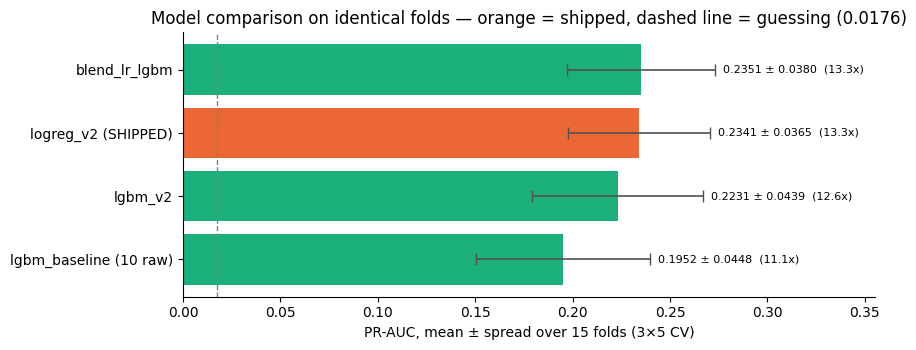

In [20]:
# 6.1 Mean ± spread of PR-AUC across the 15 folds for each candidate (parsed from the table above; no refit)
res = pd.DataFrame(rows)
res[["mean_3x5", "std_3x5"]] = res["PR-AUC_3x5"].str.split("±", expand=True).astype(float)
res = res.sort_values("mean_3x5")
fig, ax = plt.subplots(figsize=(9, 3.6))
colours = [FRAUD_C if "SHIPPED" in n else MODEL_C for n in res["model"]]
ax.barh(res["model"], res["mean_3x5"], xerr=res["std_3x5"], color=colours, capsize=4, error_kw=dict(lw=1.2, ecolor="#52514e"))
ax.axvline(BASE_RATE, ls="--", c="gray", lw=1)
for yi, (m, s, lift) in enumerate(zip(res["mean_3x5"], res["std_3x5"], res["lift_vs_base_rate"])):
    ax.text(m + s + 0.004, yi, f"{m:.4f} ± {s:.4f}  ({lift})", va="center", fontsize=8)
ax.set_xlim(0, res["mean_3x5"].max() + 0.12); ax.set_xlabel("PR-AUC, mean ± spread over 15 folds (3×5 CV)")
ax.set_title(f"Model comparison on identical folds — orange = shipped, dashed line = guessing ({BASE_RATE:.4f})"); [ax.spines[s].set_visible(False) for s in ("top", "right")]
plt.tight_layout(); plt.show()
# Takeaway: logistic regression and the blend tie; both clear LightGBM alone and the baseline; the spread bars overlap everywhere, so
# the ranking is argued on robustness and explainability, not on a decimal.


**What we found**

| Model | Score (PR-AUC, mean ± std) | vs guessing (lift) |
|---|---|---|
| 50/50 mix | 0.235 ± 0.038 | 13.3× |
| Logistic regression | 0.234 ± 0.037 | 13.3× |
| Small LightGBM | 0.223 ± 0.044 | 12.6× |
| Baseline from Section 5 | 0.195 ± 0.045 | 11.1× |

- **Logistic regression and the 50/50 mix are tied.** The gap between them (0.001) is far smaller than the normal variation.
- The variation ranges of all the models overlap (overlapping error bars), so the ranking can't be decided by a decimal place alone.
- Logistic regression does best when used as a yes/no flag (best F1 0.299): at its best cut-off it catches about **1 in 4** real positives (recall 0.27), and about **1 in 3** of its flags are correct (precision 0.34).
- It also has the most accurate probabilities (lowest Brier score, 0.01514).

**Public leaderboard check** (our uploads of each model's predictions on the 12,000 test rows; scored by the organisers, logged in `docs/leaderboard_log.md`):

| Model uploaded | Upload | Public PR-AUC |
|---|---|---|
| Logistic regression, 29 features (shipped) | #364 | **0.179** |
| 50/50 mix | #336 | 0.169 |
| Baseline LightGBM, 10 raw columns (Section 5) | #362 | 0.160 |
| Logistic regression on the 10 raw columns only (no built features) | #748 | 0.151 |

Every public score sits below its practice score (the test rows are harder: Section 2.4), but the order is the same, and the built features are worth 0.028 on the test set (0.179 vs 0.151).

**Implications: why logistic regression, not the 50/50 mix**

The mix has the higher number in the table, so the choice needs saying plainly:
1. **On our own tests they are tied.** The 0.001 gap is a rounding error next to the ±0.037 spread between folds; re-running with different splits flips the order.
2. **On the competition's public test set, logistic regression scored higher: 0.179 vs 0.169 for the mix** (and 0.167 for LightGBM alone; see `docs/leaderboard_log.md`). That set is drawn from the shifted test distribution (Section 2.4), so it is the only evidence we have from data that looks like what we will be graded on, and it points one way.
3. **Its probabilities are the most accurate** (lowest Brier score, 0.01514). The competition scores probability quality, and the alert policy in Section 7.3 prices every alert as probability × amount, so this matters twice.
4. **It is the best yes/no flagger** of the four (best F1 0.299).
5. **Fewer moving parts:** one library, and an exact reason for every flag (Section 8.2). Less to explain, and less to break in the organisers' sandbox.

The 50/50 mix is the documented backup (runner-up).


### 6.2 Why we didn't reweight the rare class
The usual fix for rare positives is to give fraud rows extra weight. We show here, on our own model and folds, what that does to the probabilities.


In [21]:
# 6.2 Same logistic regression, same 3x5 folds, with class_weight="balanced": ranking vs probability quality
def logreg_v2_weighted():
    m = logreg_v2(); m.set_params(clf=LogisticRegression(C=0.2, max_iter=5000, class_weight="balanced")); return m

aps_w, oof_w = fold_scores(logreg_v2_weighted, X, y)
aps_u, oof_u = fold_scores(logreg_v2, X, y)
cmp = pd.DataFrame({
    "PR-AUC (3x5 mean)": [aps_u.mean(), aps_w.mean()],
    "Brier (lower = better)": [brier_score_loss(y, oof_u), brier_score_loss(y, oof_w)],
    "mean predicted probability": [oof_u.mean(), oof_w.mean()],
}, index=["logistic regression (shipped)", "same, class_weight=balanced"]).round(4)
display(cmp)
print(f"true fraud rate: {y.mean():.4f}")
# Takeaway: weighting makes the ranking slightly worse and the probabilities much worse - the average predicted
# chance jumps from about 2% to about 35% against a true rate of 1.8%. This competition scores probability quality,
# and our alert rule prices every alarm as probability x amount, so inflated probabilities would misprice every alert.


,PR-AUC (3x5 mean),Brier (lower = better),mean predicted probability
logistic regression (shipped),0.2341,0.0151,0.0177
"same, class_weight=balanced",0.2152,0.1588,0.3527


true fraud rate: 0.0176


## 7. Evaluate the final model
Three questions about the logistic regression we picked in Section 6:
- **7.1** When the model says "10% chance of fraud", is it actually fraud about 10% of the time (calibration)? And where should we set the alarm?
- **7.2** Does it still work when the data is messier, like the real test data (robustness)?
- **7.3** How much money does it save?

All numbers use predictions on rows the model never saw during training (out-of-fold predictions), never the test set.


### 7.1 Can we trust the model's percentages, and where should the alarm go?
**Chart:** we sort all transactions by the model's fraud estimate and split them into 10 equal groups (deciles), from lowest risk (1) to highest risk (10). For each group, the grey bar is the fraud rate the model *predicted*, and the green bar is the fraud rate that *actually happened*.

**How to read it:** if each pair of bars is about the same height, the model's percentages can be trusted (well calibrated).

**Table:** what happens if we raise an alarm at different cut-offs (thresholds), from 2% to 50%.


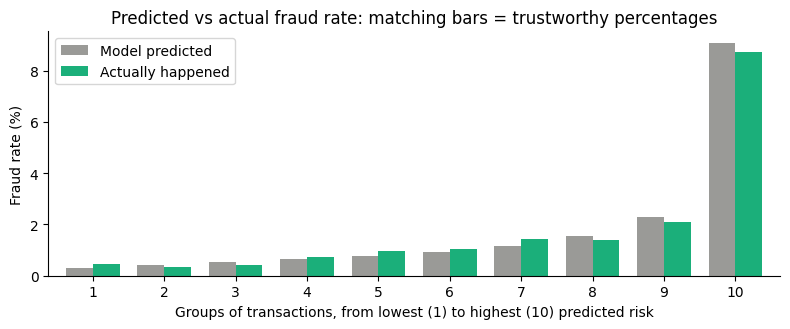

,threshold,%flagged,recall,F1,%fraud_$_caught,false_alarms_per_fraud_caught
0,0.02,17.57,0.586,0.107,84.3,16.0
1,0.05,4.65,0.397,0.218,62.6,5.6
2,0.10,1.99,0.292,0.274,48.9,2.9
3,0.20,0.88,0.207,0.277,34.7,1.4
4,0.30,0.55,0.173,0.264,32.6,0.8
5,0.50,0.30,0.119,0.203,25.8,0.4


In [22]:
BEST = "logreg_v2 (SHIPPED)"
p_best = oof[BEST]

# 7.1a Calibration: reliability curve + Brier (judging focus).
bins = pd.qcut(p_best, 10, duplicates="drop")
cal = pd.DataFrame({"mean_pred": pd.Series(p_best).groupby(bins, observed=True).mean(),
                    "actual_fraud": y.groupby(bins, observed=True).mean()})
cal.index = [str(i) for i in range(1, len(cal) + 1)]
cal.columns = ["Model predicted", "Actually happened"]
ax = (cal * 100).plot(kind="bar", figsize=(8, 3.4), rot=0, width=0.75, color=["#9a9a97", MODEL_C])
ax.set_xlabel("Groups of transactions, from lowest (1) to highest (10) predicted risk")
ax.set_ylabel("Fraud rate (%)")
ax.set_title("Predicted vs actual fraud rate: matching bars = trustworthy percentages")
[ax.spines[s].set_visible(False) for s in ("top", "right")]
plt.tight_layout(); plt.show()

# 7.1b Business threshold: flag rate vs frauds caught vs fraud DOLLARS caught.
rows = []
for t in [0.02, 0.05, 0.10, 0.20, 0.30, 0.50]:
    flag = p_best >= t
    fraud_dollars = train.loc[(y == 1), "transaction_amount"]
    caught_dollars = train.loc[(y == 1) & flag, "transaction_amount"].sum() / fraud_dollars.sum()
    rows.append({"threshold": t, "%flagged": round(100 * flag.mean(), 2),
                 "recall": round(recall_score(y, flag), 3),
                 "F1": round(f1_score(y, flag), 3),
                 "%fraud_$_caught": round(100 * caught_dollars, 1),
                 "false_alarms_per_fraud_caught": round(((flag) & (y == 0)).sum() / max(1, ((flag) & (y == 1)).sum()), 1)})
pd.DataFrame(rows)


**What we found**
- **The percentages can be trusted.** In every group, predicted and actual fraud rates are close (largest gap 0.33 percentage points). Its estimates are also more accurate than a flat 1.8% guess for everyone (Brier score 0.0151 vs 0.0173).
- **There's no single "right" alarm level.** It's a trade-off:
  - **Alarm at 10%:** flags 2% of transactions and catches 29% of fraud cases (recall), but 49% of fraud *dollars*. About 3 false alarms for every real fraud caught.
  - **Alarm at 2%:** flags 18% of transactions and catches 59% of fraud cases and 84% of fraud dollars, but with 16 false alarms for every real fraud caught.

**Implications:** we can use the model's numbers as real probabilities. Picking the alarm level is a business decision, so Section 7.3 makes it in dollars.

**A caveat on F1 and recall.** Both need a yes/no cut-off, and we only submit probabilities; we don't know which cut-off the organisers apply. At our best cut-off (about 0.135) the model scores F1 0.30 and recall 0.27; at a plain 0.50 cut-off the table above shows recall 0.12 and F1 0.20. The ranking score (PR-AUC) does not depend on this choice, and it is the main metric.


### 7.2 Does the model still work when the data gets messier?
The real test data has about 3.5× more blank values than our training data (missing values). So we run four checks:
1. **Add extra blanks** to our data at the test set's rates, and see if the score drops much.
2. **Check that blanks aren't a giveaway.** Rows that were originally blank shouldn't automatically get a near-zero fraud score (blank leak).
3. **Leave loyal big spenders alone.** Large purchases (over \$2,000) on old accounts (over 1,000 days) are usually legit, and we don't want to flag them all.
4. **Score the rows that look most like the test set** (test-like slice: the 20% of training rows most similar to the test data, from Section 2.4).


In [23]:
# 7.2 Robustness: inject extra blanks into the RAW data (the private test has ~3.5x more),
# run them through the full clean()+make_features pipeline, and score out-of-fold.
rng = np.random.default_rng(RANDOM_STATE)
test_blank = {c: test[c].isna().mean() for c in test.columns if c != ID_COL and test[c].isna().any()}
raw_holed = train.copy()
for c, rate in test_blank.items():                 # inject at the TEST's own per-column rates
    raw_holed.loc[rng.random(len(raw_holed)) < rate, c] = np.nan
X_holed = make_features(raw_holed)

oof_holed = np.zeros(len(y), dtype=float)
for tr_idx, va_idx in CV.split(X, y):
    m = logreg_v2().fit(X.iloc[tr_idx], y.iloc[tr_idx])       # shipped model, trained on clean folds
    oof_holed[va_idx] = m.predict_proba(X_holed.iloc[va_idx])[:, 1]  # score holed validation
print("PR-AUC out-of-fold — clean:", round(average_precision_score(y, p_best), 4),
      "| with extra blanks (imputed by clean()):", round(average_precision_score(y, oof_holed), 4))

# Blank-leak neutralised? Rows whose merchant_category/new_device was blank should score like anyone else.
was_blank = train.merchant_category.isna() | train.new_device.isna()
print(f"mean OOF probability — originally-blank rows: {p_best[was_blank].mean():.4f} "
      f"| all rows: {p_best.mean():.4f}  <- should be similar, NOT near zero")

big_old = (train.transaction_amount > 2000) & (train.account_age > 1000)
print(f"big+old slice (n={big_old.sum()}, fraud {train.loc[big_old, TARGET].mean():.1%}): "
      f"flagged at t=0.10: {(p_best[big_old] >= 0.10).mean():.1%}  <- keep this LOW (legit VIPs)")

# Test-like slice (top 20% adversarial P(test), defined in 2d): the private set looks more like
# these rows, so a model that only shines on typical train rows would flatter us here.
print(f"test-like slice (n={TEST_LIKE.sum()}, fraud {y[TEST_LIKE].mean():.2%}): "
      f"PR-AUC {average_precision_score(y[TEST_LIKE], p_best[TEST_LIKE]):.4f} "
      f"(lift {average_precision_score(y[TEST_LIKE], p_best[TEST_LIKE]) / y[TEST_LIKE].mean():.1f}x its base rate)")


PR-AUC out-of-fold — clean: 0.2288 | with extra blanks (imputed by clean()): 0.2219
mean OOF probability — originally-blank rows: 0.0109 | all rows: 0.0177  <- should be similar, NOT near zero
big+old slice (n=348, fraud 1.7%): flagged at t=0.10: 2.9%  <- keep this LOW (legit VIPs)
test-like slice (n=4000, fraud 3.40%): PR-AUC 0.4278 (lift 12.6x its base rate)


**What we found**
1. **Extra blanks barely hurt.** The score dips from 0.229 to 0.222 (PR-AUC −0.007).
2. **Blanks aren't a giveaway.** Originally blank rows get an average fraud score of 1.1% vs 1.8% overall: a bit lower, but not near zero.
3. **Big spenders on old accounts are mostly left alone.** Of 348 such transactions, only 2.9% are flagged at the 10% alarm level, close to the 2% flagged overall.
4. **It works on the test-like rows too.** It scores 12.6× better than guessing there (lift), similar to 13.3× on all data. (The raw score is higher, 0.43, only because fraud is more common in those rows, 3.4%, so the lift is the fairer comparison.)

**Implications:** when the data gets messier, the model gets slightly worse, not suddenly broken (degrades gracefully). One honest note: the public leaderboard score (0.179, Section 6.1) is lower than our practice score (0.234), so the test-like slice over-estimated how well the model would transfer; we treat it as a robustness check, not a forecast of the test score. A bigger set of 12 stress tests is summarised in Section 9.


### 7.3 How much money does the model save?
**Simple cost model:**
- A **missed fraud** costs the full transaction amount.
- Every **alarm** costs **\$5** to check (review cost). **This is our assumption, not a figure from the data:** the competition gives no review costs. We chose \$5 to stand for a few minutes of a fraud analyst's time plus the hassle for a genuine customer of an extra check, like an OTP or a call. A bank would swap in its own number: it is one line, `REVIEW_COST`, in the next cell.
- Because we can't verify \$5, we re-run the comparison at **\$2** (a mostly automated check) and **\$15** (a manual review, or a good customer annoyed enough to leave), and only claim conclusions that hold across that whole range (sensitivity check).

**Key idea: alarm based on the expected loss, not just the probability.**
- A **\$1,000** transaction with a 20% fraud chance → expected loss **\$200**. Much more than the \$5 check → **alarm.**
- A **\$20** transaction with the same 20% chance → expected loss **\$4**. Less than \$5 → **let it through.**

So the rule is: **alarm when probability × amount is more than \$5** (expected-loss rule).

**Chart:** net money saved per 10,000 transactions for each strategy (fraud dollars caught minus checking costs). Longer bar = better; the orange bar is the strategy we chose.

**Tables:** the strategies side by side, then how much we'd catch if the fraud team can only check a limited number of alarms.


In [24]:
# Assumptions — adjust here and re-run.
# REVIEW_COST is an ASSUMPTION, not data: the competition provides no review costs. $5 stands for a few minutes of
# analyst time plus customer friction (OTP, call); $2 and $15 bracket it (automated check / manual review or a lost
# customer). A bank replaces it with its own figure and re-runs this section.
REVIEW_COST = 5.0                      # $ per alert: analyst time + customer friction (OTP, call)
REVIEW_COST_SENSITIVITY = [2.0, 5.0, 15.0]

p_alert = p_best                       # OOF probabilities from Section 7 — never the test set
amt = train.transaction_amount.to_numpy()
is_fraud = y.to_numpy().astype(bool)
total_fraud_dollars = amt[is_fraud].sum()


,model,policy,%flagged,fraud_cases,fraud_$,saved_per_10k
0,-,no model,0.00%,0.0%,0.0%,0
1,-,rule: amount > $500,10.64%,34.3%,84.9%,80200
2,baseline LGBM (10 raw),p-threshold optimum (t=0.010),26.19%,62.9%,86.8%,74396
3,baseline LGBM (10 raw),p x amount > $5,14.31%,51.6%,87.1%,80613
4,shipped LR,p-threshold optimum (t=0.016),22.88%,64.6%,88.9%,78109
5,shipped LR,p x amount > $5,17.01%,55.8%,92.1%,84309


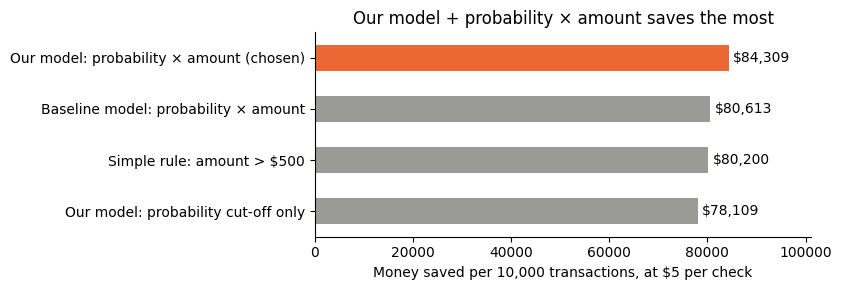

operating policy (shipped LR): alert when p x amount > $5
  precision 5.8%: about 1 in 17 flagged payments is fraud (16.3 false alarms per fraud caught)
  flags 17.01% | catches 55.8% of cases, 92.1% of fraud dollars (dollars > cases: big frauds are caught preferentially, by design)
  review cost $   2: flags 28.69%, saves $91,659/10k
  review cost $   5: flags 17.01%, saves $84,309/10k
  review cost $  15: flags  9.56%, saves $70,450/10k


,review_capacity,alerts_per_10k,fraud_cases_caught,fraud_dollars_caught
0,top 1% by p x amount,100,14.7%,49.5%
1,top 2% by p x amount,200,17.3%,52.8%
2,top 5% by p x amount,500,27.8%,75.2%


In [25]:
c = REVIEW_COST

def policy_rows(p, label):
    """The three policies for a given model's OOF probabilities, at review cost c."""
    el = p * amt
    o = np.argsort(-p); kk = np.arange(1, len(p) + 1)
    cost = (total_fraud_dollars - np.cumsum(np.where(is_fraud[o], amt[o], 0.0))) + c * kk
    t_opt = float(p[o][int(np.argmin(cost))])
    def row(name, flag):
        saved = amt[flag & is_fraud].sum() - c * flag.sum()
        return {"model": label, "policy": name, "%flagged": f"{flag.mean():.2%}",
                "fraud_cases": f"{is_fraud[flag].sum() / is_fraud.sum():.1%}",
                "fraud_$": f"{amt[flag & is_fraud].sum() / total_fraud_dollars:.1%}",
                "saved_per_10k": round(saved * 10_000 / len(train))}
    return [row(f"p-threshold optimum (t={t_opt:.3f})", p >= t_opt),
            row(f"p x amount > ${c:.0f}", el > c)]

rule = amt > 500
policies = pd.DataFrame(
    [{"model": "-", "policy": "no model", "%flagged": "0.00%", "fraud_cases": "0.0%",
      "fraud_$": "0.0%", "saved_per_10k": 0},
     {"model": "-", "policy": "rule: amount > $500", "%flagged": f"{rule.mean():.2%}",
      "fraud_cases": f"{is_fraud[rule].sum() / is_fraud.sum():.1%}",
      "fraud_$": f"{amt[rule & is_fraud].sum() / total_fraud_dollars:.1%}",
      "saved_per_10k": round((amt[rule & is_fraud].sum() - c * rule.sum()) * 10_000 / len(train))}]
    + policy_rows(oof_base, "baseline LGBM (10 raw)")
    + policy_rows(p_best, "shipped LR"))
display(policies)

sel = pd.Series({
    "Simple rule: amount > $500": policies.loc[1, "saved_per_10k"],
    "Our model: probability cut-off only": policies.loc[4, "saved_per_10k"],
    "Baseline model: probability × amount": policies.loc[3, "saved_per_10k"],
    "Our model: probability × amount (chosen)": policies.loc[5, "saved_per_10k"],
}).sort_values()
colours = [FRAUD_C if "chosen" in name else "#9a9a97" for name in sel.index]
ax = sel.plot.barh(figsize=(8.5, 3), color=colours)
ax.set_xlabel("Money saved per 10,000 transactions, at \\$5 per check")
ax.set_title("Our model + probability × amount saves the most")
ax.bar_label(ax.containers[0], labels=[f"${v:,.0f}" for v in sel], padding=3); ax.margins(x=0.2)
[ax.spines[s].set_visible(False) for s in ("top", "right")]
plt.tight_layout(); plt.savefig("money_saved_by_strategy.png", dpi=150, bbox_inches="tight"); plt.show()

exp_loss = p_best * amt
flag = exp_loss > c
print(f"operating policy (shipped LR): alert when p x amount > ${c:.0f}")
caught = int((flag & is_fraud).sum())
print(f"  precision {caught / flag.sum():.1%}: about 1 in {flag.sum() / caught:.0f} flagged payments is fraud "
      f"({(~is_fraud[flag]).sum() / caught:.1f} false alarms per fraud caught)")
print(f"  flags {flag.mean():.2%} | catches {is_fraud[flag].sum()/is_fraud.sum():.1%} of cases, "
      f"{amt[flag & is_fraud].sum()/total_fraud_dollars:.1%} of fraud dollars "
      f"(dollars > cases: big frauds are caught preferentially, by design)")
for cs in REVIEW_COST_SENSITIVITY:
    fl = exp_loss > cs
    sv = amt[fl & is_fraud].sum() - cs * fl.sum()
    print(f"  review cost ${cs:>4.0f}: flags {fl.mean():6.2%}, saves ${sv * 10_000 / len(train):,.0f}/10k")

# Review-capacity view: if the fraud team can only review the top X%, ranked by expected loss.
order_el = np.argsort(-exp_loss)
cum_d = np.cumsum(np.where(is_fraud[order_el], amt[order_el], 0.0))
cum_n = np.cumsum(is_fraud[order_el])
rows = []
for frac in [0.01, 0.02, 0.05]:
    kk = int(round(frac * len(amt)))
    rows.append({"review_capacity": f"top {frac:.0%} by p x amount", "alerts_per_10k": int(round(kk * 10_000 / len(train))),
                 "fraud_cases_caught": f"{cum_n[kk-1] / is_fraud.sum():.1%}",
                 "fraud_dollars_caught": f"{cum_d[kk-1] / total_fraud_dollars:.1%}"})
pd.DataFrame(rows)


In [26]:
# 7.3 Sensitivity: does the winning strategy change if the $5 review-cost assumption is wrong?
def saved_per_10k(flag, cost):
    return round((amt[flag & is_fraud].sum() - cost * flag.sum()) * 10_000 / len(train))

sens = []
for cost in REVIEW_COST_SENSITIVITY:
    order = np.argsort(-p_alert)
    total_cost = (total_fraud_dollars - np.cumsum(np.where(is_fraud[order], amt[order], 0.0))) + cost * np.arange(1, len(amt) + 1)
    t_best = p_alert[order][int(np.argmin(total_cost))]          # best plain probability cut-off at this cost
    ours, rule500 = saved_per_10k(p_alert * amt > cost, cost), saved_per_10k(amt > 500, cost)
    sens.append({"review cost per alarm (dollars)": int(cost),
                 "ours: probability x amount": ours,
                 "rule: amount over 500": rule500,
                 "best probability cut-off": saved_per_10k(p_alert >= t_best, cost),
                 "ours minus the 500 rule": ours - rule500})
display(pd.DataFrame(sens).set_index("review cost per alarm (dollars)"))
# Takeaway: net dollars saved per 10,000 transactions. Our rule wins at every review cost we tried, but its lead over the
# simple 500-dollar rule shrinks as checks get more expensive - a bank with costly reviews should re-run with its own figure.


,ours: probability x amount,rule: amount over 500,best probability cut-off,ours minus the 500 rule
review cost per alarm (dollars),,,,
2,91659,83393,88708,8266
5,84309,80200,78109,4109
15,70450,69555,62105,895


In [27]:
# Calibration check for the priced-alert rule: p x amount is an EXPECTED loss, so the policy
# is only as good as the probabilities are honest.
bins = pd.qcut(p_best, 10, duplicates="drop")
cal = pd.DataFrame({"mean_p": pd.Series(p_best).groupby(bins, observed=True).mean(),
                    "actual_fraud": y.groupby(bins, observed=True).mean()})
gap = float((cal.mean_p - cal.actual_fraud).abs().max())
print(f"shipped LR OOF: Brier {brier_score_loss(y, p_best):.5f} (naive {brier_score_loss(y, naive):.5f}) "
      f"| max decile |mean_p - actual| = {gap:.4f}")
# NOTE(Germaine): if any future candidate uses class weights or resampling, recalibrate on OOF
# (Platt/isotonic) BEFORE it feeds this section - otherwise p x amount misprices every alert.
# The shipped LR needs none: no weights, reliability curve ~ diagonal (Section 7.1), and isotonic
# recalibration made Brier worse in your 5x5 runs, so it is correctly NOT applied.


shipped LR OOF: Brier 0.01514 (naive 0.01734) | max decile |mean_p - actual| = 0.0033


**What we found**
We compared strategies by **money saved per 10,000 transactions** (fraud dollars caught minus checking costs):

| Strategy | Flagged | Fraud cases caught | Fraud \$ caught | Saved per 10k |
|---|---|---|---|---|
| No model | 0% | 0% | 0% | \$0 |
| Simple rule: flag everything over \$500 | 10.6% | 34% | 85% | \$80,200 |
| Our model, probability cut-off only | 22.9% | 65% | 89% | \$78,109 |
| **Our model, probability × amount > \$5** | **17.0%** | **56%** | **92%** | **\$84,309** |

- **Probability × amount wins.** It catches 92% of fraud dollars. It catches more dollars than cases because it focuses on big frauds, which is on purpose. About **1 in 17** flagged payments is real fraud (precision 5.8%).
- **The 17% flag rate is a practice-data number.** Test payments are about twice as large, and the rule flags a payment when probability × amount is over \$5, so on the test file the same rule flags about **23%** (computed in Section 10). The \$5 cut-off is the lever a bank would adjust to its review capacity.
- **A probability cut-off alone does worse than the simple \$500 rule**, because it ignores how much money is at stake.
- **The winner doesn't depend on the \$5 guess.** At **\$2** per check our rule saves **\$91,659** vs **\$83,393** for the \$500 rule; at **\$15**, **\$70,450** vs **\$69,555**. It wins at every cost we tried, but the lead shrinks as checks get pricier (only **\$895** at \$15), so a bank with expensive reviews should re-run this with its own figure.
- **If the fraud team is short-staffed** (limited review capacity) and only checks the riskiest alarms: top 1% of transactions → 49.5% of fraud dollars caught; top 5% → 75.2%.
- This rule only works if the percentages are honest, and they are: the biggest gap between predicted and actual fraud in any group is 0.0033 (confirmed in 7.1).

**Implications:** pricing each alarm by its expected loss beats both a simple dollar rule and a plain probability cut-off, by about **\$4,100** per 10,000 transactions over the \$500 rule. It's also harder for fraudsters to dodge: splitting one big fraud into many small purchases would slip under that rule, but it makes the model's "lots of activity in a short time" columns (velocity features) jump.


## 8. Explain the model
A bank has to be able to say **why** a transaction was flagged (explainability) and **who** gets bothered by false alarms (fairness). We look at the final logistic regression three ways:
- **8.1** Which signals matter most overall?
- **8.2** Why was *this* transaction flagged?
- **8.3** Are some countries' customers bothered more than others, and is that fair?


### 8.1 Which signals matter most?
**Chart:** the 12 signals that move the fraud score the most. Each bar is how strongly the model reacts to a signal, scaled by how much that signal varies between transactions (coefficient × standard deviation), so signals measured in different units can be compared fairly.

**How to read it:** red bars push the fraud score **up**, blue bars push it **down**. Longer bar = stronger effect.


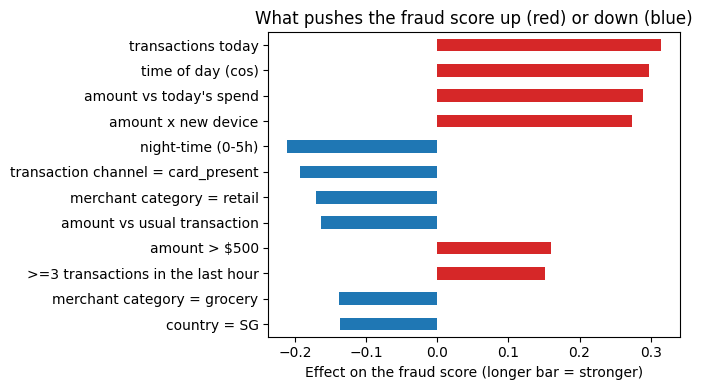

In [28]:
# 8.1 Global drivers of the shipped LR (effect size on the standardised design matrix)
lr_full = logreg_v2().fit(X, y)
pre_, clf_ = lr_full.named_steps["pre"], lr_full.named_steps["clf"]
Z_ = pre_.transform(X); Z_ = Z_.toarray() if hasattr(Z_, "toarray") else Z_
FRIENDLY = {"transactions_last_24h": "transactions today", "amt_share_24h": "amount vs today's spend",
            "log_amt_x_newdev": "amount x new device", "night": "night-time (0-5h)", "amt_vs_prev_avg": "amount vs usual transaction",
            "amt_gt500": "amount > $500", "n1_ge3": ">=3 transactions in the last hour", "n1_ge4": ">=4 transactions in the last hour",
            "n24_ge10": ">=10 transactions today", "newdev_young": "new device on a young account", "big_old": "large purchase, long-standing account",
            "night_newdev": "new device at night", "burst_young": "burst on a young account", "log_amount": "transaction amount",
            "log_age": "account age", "log_spend": "spend in last 24h", "transactions_last_1h": "transactions in last hour",
            "transaction_hour": "hour of day", "log_amt_per_age": "amount relative to account age", "burst_ratio": "share of today's activity in last hour",
            "log_amt_x_night": "amount x night", "hour_sin": "time of day (sin)", "hour_cos": "time of day (cos)", "spend_per_txn": "average transaction today",
            "new_device": "new device", "age_lt180": "account < 180 days"}
def friendly(raw):
    for c in CAT_VOCAB:
        if raw.startswith(c + "_"): return f"{c.replace('_', ' ')} = {raw[len(c) + 1:]}"
    return FRIENDLY.get(raw, raw)
names_ = [n.split("__", 1)[1] for n in pre_.get_feature_names_out()]
effect = pd.Series(clf_.coef_[0] * Z_.std(axis=0), index=[friendly(n) for n in names_])
top = effect.reindex(effect.abs().sort_values(ascending=False).index)[:12]
ax = top[::-1].plot(kind="barh", figsize=(7, 4), color=np.where(top[::-1] > 0, "C3", "C0"),
                    title="What pushes the fraud score up (red) or down (blue)")
ax.set_xlabel("Effect on the fraud score (longer bar = stronger)")
plt.tight_layout(); plt.show()
# Takeaway: velocity (transactions today / last hour), amount relative to the day's spend, and amount x new device raise risk most;
# card-present and everyday merchants (retail) lower it. These match the EDA story in Section 2 and the account-takeover pattern.

**What we found**
- **Biggest red flags:**
  - lots of transactions today, or several in the last hour (velocity)
  - a payment that's large compared to what the customer spent earlier today
  - a large payment from a new device
- **Biggest signs of safety:** paying with the physical card present (card-present), and everyday shops like retail.
- **Read the time-of-day bars as a pair.** The night-time flag and the "time of day" signals describe the same hours, so the model splits the effect between them and the bars partly cancel (overlapping features). Together they still say what Section 2.3 showed: late-night activity raises risk.

**Implications:** the model has learned the pattern we saw in Section 2.3, where someone gets into another person's account, often from a new device, and quickly makes many payments (account takeover). It hasn't latched onto a quirk of the data (artefact). A fraud analyst would point to the same warning signs.


### 8.2 Why was this transaction flagged?
For each transaction, we list the 3 signals that pushed its fraud score up the most, and by how much (contribution in log-odds; bigger number = bigger push, compared to a typical transaction). Because logistic regression simply adds these pushes up, the reasons are exact, not an approximation, so they can be shown to a customer or a fraud analyst (reason codes).

Below: the 5 riskiest transactions in the test set, with their reasons and their raw details.


In [29]:
# 8.2 Reason codes: top-3 contributions (coefficient x standardised value, log-odds units) for the riskiest test transactions
def reason_codes(model, Xq, top=3):
    pre, clf = model.named_steps["pre"], model.named_steps["clf"]
    Zq = pre.transform(Xq); Zq = Zq.toarray() if hasattr(Zq, "toarray") else Zq
    contrib = Zq * clf.coef_[0]
    cols = [friendly(n.split("__", 1)[1]) for n in pre.get_feature_names_out()]
    p = model.predict_proba(Xq)[:, 1]
    out = []
    for r in range(len(Xq)):
        order = np.argsort(-contrib[r])[:top]
        reasons = [f"{cols[j]} (+{contrib[r, j]:.2f})" for j in order if contrib[r, j] > 0]
        out.append({"p_fraud": round(float(p[r]), 3), "reasons": "; ".join(reasons)})
    return pd.DataFrame(out, index=Xq.index)

X_test_all = make_features(test)[FEATURES]
p_test = lr_full.predict_proba(X_test_all)[:, 1]
top_idx = np.argsort(-p_test)[:5]
pd.set_option("display.max_colwidth", None)
display(reason_codes(lr_full, X_test_all.iloc[top_idx]))
test.iloc[top_idx][["transaction_amount", "account_age", "new_device", "transactions_last_1h", "transactions_last_24h", "country", "merchant_category"]]
# Takeaway: the riskiest test transactions are mostly cash transfers (plus one luxury buy) from a new device on an account a few weeks old,
# with 4-8 transactions in the last hour - exactly the account-takeover pattern, and each flag can be explained to the customer.

,p_fraud,reasons
5254,0.845,transactions today (+2.21); amount x new device (+1.41); >=3 transactions in the last hour (+0.64)
8192,0.815,transactions today (+1.85); amount x new device (+1.52); >=3 transactions in the last hour (+0.64)
7578,0.807,transactions today (+2.09); amount x new device (+1.39); >=3 transactions in the last hour (+0.64)
1061,0.803,transactions today (+2.69); new device at night (+0.75); amount x new device (+0.64)
11713,0.796,transactions today (+2.21); amount x new device (+1.29); >=3 transactions in the last hour (+0.64)


,transaction_amount,account_age,new_device,transactions_last_1h,transactions_last_24h,country,merchant_category
5254,1558.88,102.0,1.0,6.0,23.0,ID,cash_transfer
8192,2662.17,52.0,1.0,4.0,20.0,GB,luxury
7578,1432.70,83.0,1.0,5.0,22.0,VN,cash_transfer
1061,34.69,45.0,1.0,8.0,27.0,ID,cash_transfer
11713,865.90,90.0,1.0,4.0,23.0,VN,cash_transfer


**What we found**
- The 5 riskiest test transactions have an **80–85% fraud chance**. They are mostly cash transfers (plus one luxury purchase), all from a **new device**, on accounts only **45–102 days old**, with **4–8 transactions in the last hour**.
- Each one comes with plain-English reasons, for example: *"transactions today (+2.21); amount × new device (+1.41); ≥3 transactions in the last hour (+0.64)"*.

**Implications:** every alarm can be explained in one sentence. A fraud analyst needs this to decide quickly, and a customer needs it to challenge a wrong decision. Singapore's financial regulator requires that kind of appeal process in its fairness and ethics principles for AI (MAS FEAT, principle 13).


### 8.3 Who gets bothered, and is that fair?
Using the 10% alarm level from Section 7, for each country we check:
- what share of **honest customers get wrongly flagged** (false positive rate, FPR)
- what share of **real fraud gets caught** (recall)

**Chart:** honest customers wrongly flagged, by country. The dashed line is the average across all customers. Taller bar = more honest customers bothered.

Then we retrain the same model **without the country column**, to see whether we actually need it. This follows Singapore's financial regulator's fairness principles (MAS FEAT, principles 1–3).


,n,actual fraud %,flag %,FPR % (legit flagged),recall
country,,,,,
ID,840,4.05,6.79,5.46,0.38
AU,584,2.91,5.99,4.06,0.71
PH,581,3.44,5.34,3.57,0.55
US,693,3.17,5.05,3.28,0.59
JP,382,3.40,4.45,2.98,0.46
VN,508,3.74,5.12,2.86,0.63
GB,505,3.17,3.76,2.66,0.38
TH,644,1.71,2.95,2.05,0.55
unknown,107,0.93,1.87,1.89,0.00


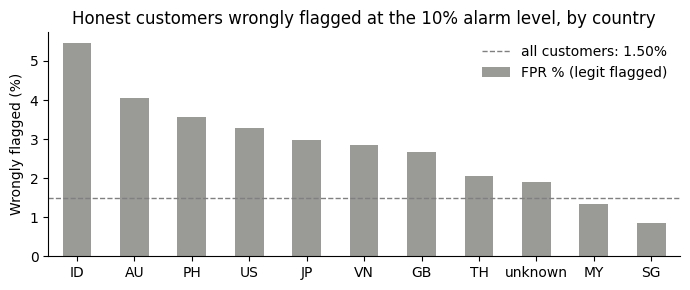

SG holds 182 of the 353 fraud cases in the training data (52%) and 70% of all rows


PR-AUC with country: 0.2341 +/- 0.0365 | without country: 0.2352 +/- 0.0339 | cost of dropping it: -0.0011


In [30]:
# 8.3 Fairness by country at the operating threshold (MAS FEAT): who gets disrupted, and what `country` is worth
def fairness_by_group(y_true, p, group, threshold):
    y_true, p = np.asarray(y_true), np.asarray(p); flag = p >= threshold; rows = []
    for g in pd.Series(group).unique():
        m = (np.asarray(group) == g); yy, ff = y_true[m], flag[m]
        rows.append({"country": g, "n": int(m.sum()), "actual fraud %": 100 * yy.mean(), "flag %": 100 * ff.mean(),
                     "FPR % (legit flagged)": 100 * ff[yy == 0].mean(), "recall": ff[yy == 1].mean() if (yy == 1).any() else np.nan})
    return pd.DataFrame(rows).set_index("country").round(2).sort_values("FPR % (legit flagged)", ascending=False)

THRESHOLD = 0.10
fair = fairness_by_group(y, p_best, train.country.fillna("unknown"), THRESHOLD)
display(fair)
overall_fpr = 100 * (p_best[y.to_numpy() == 0] >= THRESHOLD).mean()
ax = fair["FPR % (legit flagged)"].plot(kind="bar", figsize=(7, 3), rot=0, color="#9a9a97",
        title=f"Honest customers wrongly flagged at the {THRESHOLD:.0%} alarm level, by country")
ax.axhline(overall_fpr, ls="--", c="gray", lw=1, label=f"all customers: {overall_fpr:.2f}%")
ax.set_ylabel("Wrongly flagged (%)"); ax.set_xlabel("")
ax.legend(frameon=False)
[ax.spines[s].set_visible(False) for s in ("top", "right")]
plt.tight_layout(); plt.show()
print(f"SG holds {int(y[train.country == 'SG'].sum())} of the {int(y.sum())} fraud cases in the training data "
      f"({y[train.country == 'SG'].sum() / y.sum():.0%}) and {(train.country == 'SG').mean():.0%} of all rows")

# What does `country` buy us? Same model without it, same 3x5 folds.
NUMS_NC, FLAGS_NC = NUMS, FLAGS
def logreg_no_country():
    pre = ColumnTransformer([
        ("cat", OneHotEncoder(categories=[CAT_VOCAB[c] for c in ("merchant_category", "transaction_channel")], handle_unknown="ignore"),
         ["merchant_category", "transaction_channel"]),
        ("num", StandardScaler(), NUMS_NC), ("flag", "passthrough", FLAGS_NC)])
    return Pipeline([("pre", pre), ("clf", LogisticRegression(C=0.2, max_iter=5000))])
aps_nc, _ = fold_scores(logreg_no_country, X, y)
aps_lr, _ = fold_scores(logreg_v2, X, y)
print(f"PR-AUC with country: {aps_lr.mean():.4f} +/- {aps_lr.std():.4f} | without country: {aps_nc.mean():.4f} +/- {aps_nc.std():.4f} "
      f"| cost of dropping it: {aps_lr.mean() - aps_nc.mean():+.4f}")
# Takeaway: a legitimate ID customer is ~6x and an AU customer ~5x more likely to be flagged than a SG one, and the model catches only 9% of SG fraud
# (SG fraud looks like normal SG behaviour), even though SG holds over half of the fraud cases in the training data. Dropping `country` costs nothing
# in cross-validation (within ±0.002 PR-AUC) but cost ~0.013 on the public leaderboard, so it is a trade-off, not free. Monitor this table at every
# retrain (FEAT P1-P3).


**What we found**
- **Honest customers in some countries get flagged far more often:** 5.5% in Indonesia (ID) and 4.1% in Australia (AU), vs 0.85% in Singapore (SG), a 6.4× gap. Part of this is expected, because fraud really is more common in those countries (4.1% in ID vs 1.3% in SG). But the flagging gap (6.4×) is about twice as big as the fraud gap (about 3×).
- **The model is weakest in Singapore.** It catches only 9% of Singapore fraud (recall 0.09), vs 38–71% elsewhere. Singapore fraud looks like normal Singapore behaviour, so there's little for the model to spot. This matters a lot: most transactions in the training data are from Singapore, so **182 of the 353 fraud cases** in the training data are Singaporean, more than half.
- **Removing country doesn't hurt in our tests:** score 0.2352 ± 0.0339 without it vs 0.2341 ± 0.0365 with it.

**Implications:** the false alarms fall unevenly across countries, and the country column doesn't improve our cross-validation score. So a version without it (fairness-constrained variant) is a real option. But on the competition's public test, country was worth about 0.013, so dropping it is a trade-off, not free. Whichever version is used, this table should be checked every time the model is retrained (monitoring).


## 9. Limitations and next steps
**Little fraud to learn from.** 353 examples; scores swing ±0.04 between folds, so we report means over repeated cross-validation and never switch models on one number. No customer ID or timestamp, so per-customer baselines — the strongest real-world fraud features — are impossible here.

**Frauds with no signal.** A fraud on a known device, an old account, with an ordinary amount and no burst looks like any other transaction. The cell below counts how many training frauds look like that.


In [31]:
# 9. Frauds with no observable signal: known device, account older than a year, amount under 300, at most 2 transactions in the last hour
quiet = ((train.new_device == 0) & (train.account_age > 365) & (train.transaction_amount < 300) & (train.transactions_last_1h <= 2))
n_quiet_fraud = int((quiet & (train[TARGET] == 1)).sum()); n_fraud = int(train[TARGET].sum())
sg_share = train.loc[quiet & (train[TARGET] == 1), "country"].eq("SG").mean()
display(Markdown(f"**{n_quiet_fraud} of {n_fraud} training frauds ({n_quiet_fraud / n_fraud:.0%}, about 1 in {n_fraud / n_quiet_fraud:.0f})** show none of the "
                 f"signals the model relies on; {sg_share:.0%} of them are Singapore transactions. Their quiet-looking peers: "
                 f"**{quiet.sum():,} rows at a {100 * train.loc[quiet, TARGET].mean():.2f}% fraud rate** — below the 1.76% overall."))


**62 of 353 training frauds (18%, about 1 in 6)** show none of the signals the model relies on; 74% of them are Singapore transactions. Their quiet-looking peers: **10,182 rows at a 0.61% fraud rate** — below the 1.76% overall.

These frauds are indistinguishable from ordinary transactions on the columns we have, so **no model catches them**; they set a hard ceiling on recall. Most are domestic, which is why Singapore recall is only 0.09 (Section 8.3).

**Fairness.** Legitimate ID and AU customers are flagged 6.4× more often than SG ones (Section 8.3); dropping `country` costs nothing in cross-validation. A bank should keep the fairness-constrained variant as a live option and monitor Section 8.3 at every retrain.

**The test set is different from the training set.** We measured it (Section 2.4) and the public leaderboard confirms it: every model scores lower there than in cross-validation (ours 0.179 vs 0.234), and the private set may differ again. Our score there could therefore be lower than our own estimates. We planned for this rather than chased it: blanks imputed, numbers clipped to training ranges, every model also scored on a test-like slice and under injected blanks (Section 7.2), a 12-scenario stress test (`src/stress_test.py`) that crashes nothing, and no tuning to the public leaderboard, where ranks within ±0.03 are noise.

**Next:** customer history and timestamps, scheduled retraining, calibration monitoring ("does 30% still mean 30%?"), the fairness-constrained deployment option.


## 10. Ship it: save the model, write the predictions
*This section adds no analysis. It only shows how the submission files were produced, so the result can be reproduced.*

Two cells. The first trains the shipped logistic regression on all 20,000 rows and saves `model.pkl`; it uses standard scikit-learn classes only, so it loads in the organisers' sandbox with no custom code, provided it is trained under the pinned library versions (`requirements-image.txt`). The second reloads that file exactly as `notebooks/prediction.ipynb` does (probabilities via `predict_proba`, as in the organisers' template) and writes the public-leaderboard CSV (`id,prediction` in `test.csv` order), checking it against `sample_submission.csv` when present. The sandbox upload is `prediction.ipynb` plus `model.pkl`; it inlines the same `clean` and `make_features` code as Sections 3–4 and must stay identical to it.


In [32]:
final_model = logreg_v2().fit(X, y)                 # shipped: LR on the 29 v2 features (blend = runner-up)
joblib.dump((final_model, FEATURES), "model.pkl")

# Verify exactly as prediction.ipynb will consume it:
loaded, feats = joblib.load("model.pkl")
Xt = make_features(test)[feats]
check = loaded.predict_proba(Xt)[:, 1] if hasattr(loaded, "predict_proba") else loaded.predict(Xt)
assert len(check) == len(test) and 0 <= check.min() <= check.max() <= 1
print("model.pkl OK — probabilities:", np.round(check[:5], 4))


model.pkl OK — probabilities: [0.0055 0.0137 0.007  0.008  0.0042]


In [33]:
model, features = joblib.load("model.pkl")
test_df = pd.read_csv(TEST_PATH)
X_test = make_features(test_df)[features]
preds = (model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba")
         else model.predict(X_test))

flag_test = preds * test_df["transaction_amount"].to_numpy() > REVIEW_COST
print(f"alert rule (p x amount > ${REVIEW_COST:.0f}) on the TEST file: flags {flag_test.mean():.2%} of 12,000 payments "
      f"(vs 17.0% in cross-validation; test payments average ${test_df.transaction_amount.mean():,.0f} vs ${train.transaction_amount.mean():,.0f})")

sub = pd.DataFrame({"id": test_df[ID_COL], "prediction": preds})
sub.to_csv("submission.csv", index=False)
assert list(sub.columns) == ["id", "prediction"]
assert len(sub) == len(test_df) and sub.id.str.fullmatch(r"FR\d{6}").all()
assert 0 <= sub.prediction.min() <= sub.prediction.max() <= 1

sample = find_csv(["sample_submission.csv"], required=False)  # official template, only if present
if sample is not None:
    s = pd.read_csv(sample)
    if list(s.columns) == list(sub.columns) and (s.id.values == sub.id.values).all():
        print("matches sample_submission.csv: columns and row order OK")
    else:
        print("WARNING: format differs from sample_submission.csv - check before uploading")
else:
    print("sample_submission.csv not found - skipped the optional format check")
print(f"wrote submission.csv: {len(sub)} rows, mean p {preds.mean():.4f}")
sub.head(3)


alert rule (p x amount > $5) on the TEST file: flags 22.96% of 12,000 payments (vs 17.0% in cross-validation; test payments average $524 vs $253)
matches sample_submission.csv: columns and row order OK
wrote submission.csv: 12000 rows, mean p 0.0216


,id,prediction
0,FR021005,0.005495
1,FR030078,0.013705
2,FR020717,0.006970
